# XLM-RoBERTa Sentiment Experiments: Single, Cross-Variety, and Combined Training

This notebook runs the sentiment workflow with **xlm-roberta-base**:
- pooled training across all varieties
- cross-variety transfer evaluation (train on one variety, test on all)
- combined training evaluation by target variety
- comparison plots against saved RoBERTa results


In [1]:
# Install required libraries (run once)
%pip install -q datasets transformers accelerate scikit-learn matplotlib seaborn pandas numpy sentencepiece protobuf tiktoken imbalanced-learn bert-score evaluate peft nlpaug nltk

Note: you may need to restart the kernel to use updated packages.


In [ ]:
import os
import random
import pickle
import warnings
from pathlib import Path
from typing import Dict, List, Optional, Tuple, Any

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import load_dataset

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
    roc_curve,
    matthews_corrcoef,
)
from sklearn.utils.class_weight import compute_class_weight

import torch
import torch.nn.functional as F
from torch.utils.data import Dataset

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
    TrainerCallback,
    DataCollatorWithPadding,
)

import time

warnings.filterwarnings('ignore', category=FutureWarning)
sns.set_theme(style='whitegrid', context='talk')
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['savefig.facecolor'] = 'white'
plt.rcParams['figure.dpi'] = 100

# Model setup
MODEL_LABEL = 'XLM-RoBERTa'
MODEL_NAME  = 'xlm-roberta-base'
TASK        = 'Sentiment'   # Sentiment only
TASKS       = ['Sentiment']
VARIETIES   = ['en-AU', 'en-IN', 'en-UK']
SEEDS       = [42, 123, 456]   # 3 seeds for statistical significance
MAX_LEN     = 128
NUM_TRAINING_RUNS = 3

# GPU detection and mixed precision
def get_compute_dtype():
    """Detect GPU and select optimal precision."""
    if torch.cuda.is_available():
        major = torch.cuda.get_device_properties(0).major
        if major >= 8:   # Ampere+ -> BF16
            print(f"  GPU compute capability: sm_{major}x -> using BF16")
            return torch.bfloat16, False, True
        else:            # Turing/Volta -> FP16
            print(f"  GPU compute capability: sm_{major}x -> using FP16")
            return torch.float16, True, False
    return torch.float32, False, False

COMPUTE_DTYPE, USE_FP16, USE_BF16 = get_compute_dtype()

# GPU-optimized training settings
# xlm-roberta-base (~270M params) is lighter than RemBERT/DeBERTa,
# so we can use a larger batch size for the same VRAM budget.
BATCH_SIZE_TRAIN          = 16   # effective batch = 16 * 2 = 32
BATCH_SIZE_EVAL           = 32
GRADIENT_ACCUMULATION_STEPS = 2
NUM_EPOCHS                = 5
LEARNING_RATE             = 2e-5
LEARNING_RATE_LORA        = 2e-4
WEIGHT_DECAY              = 0.01
WARMUP_RATIO              = 0.1
MAX_GRAD_NORM             = 1.0
EARLY_STOPPING_PATIENCE   = 3
LOGGING_STEPS             = 25

# Device setup
if torch.cuda.is_available():
    DEVICE = torch.device('cuda')
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
    if torch.cuda.get_device_properties(0).major >= 8:
        torch.set_float32_matmul_precision('high')
elif hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
else:
    DEVICE = torch.device('cpu')

# OUT_DIR = Path('/scratch/HS400/outputs_xlmroberta')
OUT_DIR = Path(os.getcwd()) / 'outputs_xlmroberta'
OUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Model:           {MODEL_NAME}")
print(f"Device:          {DEVICE}")
print(f"FP16: {USE_FP16}, BF16: {USE_BF16}")
print(f"Effective Batch: {BATCH_SIZE_TRAIN * GRADIENT_ACCUMULATION_STEPS}")
print(f"Outputs:         {OUT_DIR.resolve()}")

# Checkpoint and resume setup
RESUME_FROM_CHECKPOINT = True

def check_experiment_completed(experiment_name: str, task_name: str = None) -> bool:
    if not RESUME_FROM_CHECKPOINT:
        return False
    check_paths = []
    if task_name:
        task_dir = OUT_DIR / task_name.lower()
        check_paths.extend([
            task_dir / f'{experiment_name}.csv',
            task_dir / f'{experiment_name}.pkl',
            task_dir / 'final_models' / experiment_name,
        ])
    else:
        check_paths.extend([
            OUT_DIR / f'{experiment_name}.csv',
            OUT_DIR / f'{experiment_name}.pkl',
            OUT_DIR / experiment_name,
        ])
    for path in check_paths:
        if path.exists():
            print(f"  [SKIP] Found existing: {path}")
            return True
    return False


def task_out_dir(task_name: str) -> Path:
    d = OUT_DIR / task_name.lower()
    d.mkdir(parents=True, exist_ok=True)
    return d


def get_label_col(task_name: str) -> str:
    task_lower = task_name.lower()
    if task_lower == 'sentiment':
        return sentiment_col
    else:
        raise ValueError(f"Unknown task: {task_name}. This notebook is Sentiment-only.")


print("Configuration loaded successfully!")

  GPU compute capability: sm_8x -> using BF16
GPU: NVIDIA RTX A4000
VRAM: 16.7 GB
Model:           xlm-roberta-base
Device:          cuda
FP16: False, BF16: True
Effective Batch: 32
Outputs:         /scratch/HS400/outputs_xlmroberta
Configuration loaded successfully!


In [3]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def find_file(name: str):
    candidates = [
        Path(name),
        Path('./all_outputs') / name,
        Path('../all_outputs') / name,
        Path('../../all_outputs') / name,
        Path('../2.1. Classical vs Transformer/results') / name,
    ]
    for c in candidates:
        if c.exists():
            return c
    matches = list(Path('.').rglob(name))
    return matches[0] if matches else None

In [4]:
# Load dataset
pooled = load_dataset('surrey-nlp/BESSTIE-CW-26')

train_cols = list(pooled['train'].column_names)

def _pick_col(candidates, cols, required=True):
    for c in candidates:
        if c in cols:
            return c
    if required:
        raise ValueError(f"None of candidate columns {candidates} found in dataset columns: {cols}")
    return None

text_col      = _pick_col(['text', 'content', 'sentence', 'review'], train_cols)
sentiment_col = _pick_col(['sentiment', 'Sentiment', 'sentiment_label', 'label_sentiment', 'sentiment_class'], train_cols)
variety_col   = _pick_col(['variety', 'english_variety', 'dialect'], train_cols)

label_col = sentiment_col

for split in ['train', 'validation', 'test']:
    print(split, len(pooled[split]))

print('Columns:', train_cols)
print('Using -> text_col:', text_col, '| label_col:', label_col, '| variety_col:', variety_col)

train 3747
validation 313
test 2183
Columns: ['text', 'variety', 'source', 'Sentiment', 'Sarcasm']
Using -> text_col: text | label_col: Sentiment | variety_col: variety


## Base Model Snapshot (Before Fine-Tuning)

Save the original pretrained XLM-RoBERTa model once so we can compare results before and after fine-tuning.


In [5]:
BASE_DIR = OUT_DIR / 'base_model'
BASE_DIR.mkdir(parents=True, exist_ok=True)

# XLM-RoBERTa uses a fast SentencePiece tokenizer; use_fast=True is fine.
base_tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True)
base_model     = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)

base_model.save_pretrained(str(BASE_DIR))
base_tokenizer.save_pretrained(str(BASE_DIR))

print('Saved base model snapshot to:', BASE_DIR.resolve())

config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.bias                | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
classifier.dense.bias       | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.out_proj.weight  | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved base model snapshot to: /scratch/HS400/outputs_xlmroberta/base_model


In [6]:
class TextDataset(Dataset):
    """Custom dataset for text classification with tokenization."""

    def __init__(self, texts: List[str], labels: List[int], tokenizer, max_len: int = 128):
        self.texts     = texts
        self.labels    = labels
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self) -> int:
        return len(self.texts)

    def __getitem__(self, idx: int) -> Dict[str, torch.Tensor]:
        enc  = self.tokenizer(
            self.texts[idx],
            truncation=True,
            padding='max_length',
            max_length=self.max_len,
            return_tensors='pt',
        )
        item = {k: v.squeeze(0) for k, v in enc.items()}
        item['labels'] = torch.tensor(int(self.labels[idx]), dtype=torch.long)
        return item


class IntLabelDataCollator(DataCollatorWithPadding):
    """Ensures labels are torch.long (safe for mixed-precision training)."""

    def __call__(self, features):
        batch = super().__call__(features)
        if 'labels' in batch:
            batch['labels'] = batch['labels'].to(torch.long)
        return batch


def compute_metrics(eval_pred) -> Dict[str, float]:
    logits, labels = eval_pred
    preds  = np.argmax(logits, axis=-1)
    probs  = torch.softmax(torch.tensor(logits), dim=-1).numpy()

    metrics = {
        'accuracy':          accuracy_score(labels, preds),
        'macro_f1':          f1_score(labels, preds, average='macro',    zero_division=0),
        'macro_precision':   precision_score(labels, preds, average='macro',    zero_division=0),
        'macro_recall':      recall_score(labels, preds, average='macro',    zero_division=0),
        'weighted_f1':       f1_score(labels, preds, average='weighted', zero_division=0),
        'weighted_precision':precision_score(labels, preds, average='weighted', zero_division=0),
        'weighted_recall':   recall_score(labels, preds, average='weighted', zero_division=0),
    }

    per_class_f1 = f1_score(labels, preds, average=None, zero_division=0, labels=[0, 1])
    metrics['class_0_f1'] = float(per_class_f1[0]) if len(per_class_f1) > 0 else 0.0
    metrics['class_1_f1'] = float(per_class_f1[1]) if len(per_class_f1) > 1 else 0.0

    try:
        if len(np.unique(labels)) == 2:
            metrics['roc_auc']       = roc_auc_score(labels, probs[:, 1])
            metrics['avg_precision'] = average_precision_score(labels, probs[:, 1])
    except Exception:
        pass

    return metrics


class TrainingHistoryCallback(TrainerCallback):
    """Tracks training/validation metrics over epochs."""

    def __init__(self):
        self.train_losses  = []
        self.eval_losses   = []
        self.eval_metrics  = []
        self.learning_rates = []

    def on_log(self, args, state, control, logs=None, **kwargs):
        if logs:
            if 'loss' in logs:
                self.train_losses.append({'step': state.global_step, 'epoch': state.epoch, 'loss': logs['loss']})
            if 'learning_rate' in logs:
                self.learning_rates.append({'step': state.global_step, 'lr': logs['learning_rate']})

    def on_evaluate(self, args, state, control, metrics=None, **kwargs):
        if metrics:
            self.eval_losses.append({'step': state.global_step, 'epoch': state.epoch, 'eval_loss': metrics.get('eval_loss')})
            rec = {'step': state.global_step, 'epoch': state.epoch}
            rec.update({k: v for k, v in metrics.items() if k.startswith('eval_')})
            self.eval_metrics.append(rec)


class WeightedTrainer(Trainer):
    """Custom Trainer with class-weighted cross-entropy loss."""

    def __init__(self, class_weights: Optional[np.ndarray] = None, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self._class_weights = torch.tensor(class_weights, dtype=torch.float32) if class_weights is not None else None

    def _get_loss_fn(self, device):
        if self._class_weights is not None:
            weight = self._class_weights.to(device=device, dtype=torch.float32)
            return torch.nn.CrossEntropyLoss(weight=weight)
        return torch.nn.CrossEntropyLoss()

    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels  = inputs.pop('labels')
        outputs = model(**inputs)
        logits  = outputs.get('logits')
        loss_fn = self._get_loss_fn(logits.device)
        loss    = loss_fn(logits.float().view(-1, model.config.num_labels), labels.view(-1))
        if torch.isnan(loss):
            loss = (logits.sum() * 0.0) + 10.0
        return (loss, outputs) if return_outputs else loss


class FocalLossTrainer(Trainer):
    """Trainer using Focal Loss for highly imbalanced / hard-to-classify data."""

    def __init__(self, gamma: float = 2.0, class_weights: Optional[np.ndarray] = None, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.gamma  = gamma
        self.weight = torch.tensor(class_weights, dtype=torch.float32) if class_weights is not None else None

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels  = inputs.pop('labels')
        outputs = model(**inputs)
        logits  = outputs.get('logits').float()
        dev_wt  = self.weight.to(logits.device) if self.weight is not None else None
        ce_loss = F.cross_entropy(logits.view(-1, model.config.num_labels), labels.view(-1), weight=dev_wt, reduction='none')
        pt      = torch.exp(-ce_loss)
        loss    = ((1 - pt) ** self.gamma * ce_loss).mean()
        if torch.isnan(loss):
            loss = (logits.sum() * 0.0) + 10.0
        return (loss, outputs) if return_outputs else loss


def get_trainer(
    model,
    args: TrainingArguments,
    train_dataset,
    eval_dataset,
    tokenizer,
    class_weights: Optional[np.ndarray] = None,
    use_weighted_loss: bool = False,
    use_focal_loss: bool = False,
    callbacks: List = None,
):
    """Factory function: returns WeightedTrainer, FocalLossTrainer, or standard Trainer."""
    data_collator = IntLabelDataCollator(tokenizer)
    if callbacks is None:
        callbacks = [EarlyStoppingCallback(early_stopping_patience=EARLY_STOPPING_PATIENCE)]

    if use_focal_loss and class_weights is not None:
        print('  Using FocalLossTrainer with class weights (gamma=2.0)')
        return FocalLossTrainer(
            gamma=2.0, class_weights=class_weights,
            model=model, args=args, train_dataset=train_dataset, eval_dataset=eval_dataset,
            data_collator=data_collator, compute_metrics=compute_metrics, callbacks=callbacks,
        )
    elif use_weighted_loss and class_weights is not None:
        print('  Using WeightedTrainer with class weights')
        return WeightedTrainer(
            class_weights=class_weights,
            model=model, args=args, train_dataset=train_dataset, eval_dataset=eval_dataset,
            data_collator=data_collator, compute_metrics=compute_metrics, callbacks=callbacks,
        )
    else:
        print('  Using standard Trainer (data balanced via resampling)')
        return Trainer(
            model=model, args=args, train_dataset=train_dataset, eval_dataset=eval_dataset,
            data_collator=data_collator, compute_metrics=compute_metrics, callbacks=callbacks,
        )


print('Loaded: TextDataset, IntLabelDataCollator, compute_metrics')
print('Loaded: WeightedTrainer, FocalLossTrainer, get_trainer')
print('Loaded: TrainingHistoryCallback')

Loaded: TextDataset, IntLabelDataCollator, compute_metrics
Loaded: WeightedTrainer, FocalLossTrainer, get_trainer
Loaded: TrainingHistoryCallback


In [ ]:
# Plotting helpers

def plot_training_history(history_callback: TrainingHistoryCallback, save_path: Path, title_prefix: str = ''):
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    if history_callback.train_losses:
        df = pd.DataFrame(history_callback.train_losses)
        axes[0, 0].plot(df['step'], df['loss'], 'b-', alpha=0.7, label='Train Loss')
        axes[0, 0].set_xlabel('Step'); axes[0, 0].set_ylabel('Loss')
        axes[0, 0].set_title('Training Loss', fontweight='bold'); axes[0, 0].legend(); axes[0, 0].grid(alpha=0.3)

    if history_callback.eval_losses:
        df = pd.DataFrame(history_callback.eval_losses).dropna(subset=['eval_loss'])
        if not df.empty:
            axes[0, 1].plot(df['epoch'], df['eval_loss'], 'r-o', label='Eval Loss')
            axes[0, 1].set_xlabel('Epoch'); axes[0, 1].set_ylabel('Loss')
            axes[0, 1].set_title('Validation Loss', fontweight='bold'); axes[0, 1].legend(); axes[0, 1].grid(alpha=0.3)

    if history_callback.eval_metrics:
        df = pd.DataFrame(history_callback.eval_metrics)
        for col, label, style in [('eval_macro_f1', 'Macro F1', 'g-o'), ('eval_class_0_f1', 'Class 0 F1', 'r--s'), ('eval_class_1_f1', 'Class 1 F1', 'b--^')]:
            if col in df.columns:
                axes[1, 0].plot(df['epoch'], df[col], style, label=label, linewidth=2, alpha=0.8)
        axes[1, 0].set_xlabel('Epoch'); axes[1, 0].set_ylabel('F1 Score')
        axes[1, 0].set_ylim(0, 1); axes[1, 0].set_title('F1 Scores Over Epochs', fontweight='bold')
        axes[1, 0].legend(); axes[1, 0].grid(alpha=0.3)

    if history_callback.learning_rates:
        df = pd.DataFrame(history_callback.learning_rates)
        axes[1, 1].plot(df['step'], df['lr'], 'c-', label='Learning Rate')
        axes[1, 1].set_xlabel('Step'); axes[1, 1].set_ylabel('Learning Rate')
        axes[1, 1].set_title('Learning Rate Schedule', fontweight='bold')
        axes[1, 1].legend(); axes[1, 1].grid(alpha=0.3)
        axes[1, 1].ticklabel_format(style='sci', axis='y', scilimits=(0, 0))

    if title_prefix:
        plt.suptitle(title_prefix.strip(' -'), fontweight='bold', fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    return fig


def plot_confusion_matrix(cm: np.ndarray, save_path: Path, title: str = 'Confusion Matrix'):
    fig, ax = plt.subplots(figsize=(8, 6))
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    im = ax.imshow(cm_norm, cmap='Blues', vmin=0, vmax=1)
    plt.colorbar(im, ax=ax, fraction=0.046).set_label('Proportion', rotation=270, labelpad=15)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            color = 'white' if cm_norm[i, j] > 0.5 else 'black'
            ax.text(j, i, f'{cm[i,j]}\n({cm_norm[i,j]:.1%})', ha='center', va='center', color=color, fontsize=12, fontweight='bold')
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(['Negative (0)', 'Positive (1)']); ax.set_yticklabels(['Negative (0)', 'Positive (1)'])
    ax.set_xlabel('Predicted', fontweight='bold'); ax.set_ylabel('True', fontweight='bold')
    ax.set_title(title, fontweight='bold', fontsize=14)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    return fig


def plot_roc_pr_curves(y_true: np.ndarray, y_probs: np.ndarray, save_path: Path, title_prefix: str = ''):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    fpr, tpr, _ = roc_curve(y_true, y_probs)
    auc_val     = roc_auc_score(y_true, y_probs)
    axes[0].plot(fpr, tpr, 'b-', lw=2, label=f'ROC (AUC={auc_val:.3f})')
    axes[0].plot([0, 1], [0, 1], 'k--', lw=1, label='Random')
    axes[0].fill_between(fpr, tpr, alpha=0.2)
    axes[0].set_xlim([0, 1]); axes[0].set_ylim([0, 1.05])
    axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
    axes[0].set_title(f'{title_prefix}ROC Curve', fontweight='bold')
    axes[0].legend(loc='lower right'); axes[0].grid(alpha=0.3)
    prec, rec, _ = precision_recall_curve(y_true, y_probs)
    ap = average_precision_score(y_true, y_probs)
    axes[1].plot(rec, prec, 'r-', lw=2, label=f'PR (AP={ap:.3f})')
    axes[1].fill_between(rec, prec, alpha=0.2, color='red')
    axes[1].set_xlim([0, 1]); axes[1].set_ylim([0, 1.05])
    axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
    axes[1].set_title(f'{title_prefix}PR Curve', fontweight='bold')
    axes[1].legend(loc='lower left'); axes[1].grid(alpha=0.3)
    if title_prefix:
        plt.suptitle(title_prefix.strip(' -'), fontweight='bold', fontsize=14)
    
    plt.tight_layout(rect=[0, 0.03, 1, 0.92])
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    return fig


def get_training_args(output_dir: str, seed: int, use_lora: bool = False) -> TrainingArguments:
    lr = LEARNING_RATE_LORA if use_lora else LEARNING_RATE
    return TrainingArguments(
        output_dir=output_dir,
        num_train_epochs=NUM_EPOCHS,
        per_device_train_batch_size=BATCH_SIZE_TRAIN,
        per_device_eval_batch_size=BATCH_SIZE_EVAL,
        gradient_accumulation_steps=GRADIENT_ACCUMULATION_STEPS,
        learning_rate=lr,
        weight_decay=WEIGHT_DECAY,
        warmup_ratio=WARMUP_RATIO,
        max_grad_norm=MAX_GRAD_NORM,
        eval_strategy='epoch',
        save_strategy='epoch',
        load_best_model_at_end=True,
        metric_for_best_model='macro_f1',
        greater_is_better=True,
        save_total_limit=2,
        save_only_model=True,
        logging_steps=LOGGING_STEPS,
        logging_first_step=True,
        seed=seed,
        data_seed=seed,
        fp16=USE_FP16,
        bf16=USE_BF16,
        fp16_full_eval=False,
        dataloader_num_workers=0,  # was 2 - Windows multiprocessing deadlocks in Jupyter/%run context
        dataloader_prefetch_factor=None,  # must be None when num_workers=0
        dataloader_pin_memory=False,  # pin_memory also causes issues with num_workers=0 on Windows
        report_to='none',
        disable_tqdm=False,
    )


print('Loaded: plot_training_history, plot_confusion_matrix, plot_roc_pr_curves')
print('Loaded: get_training_args')

Loaded: plot_training_history, plot_confusion_matrix, plot_roc_pr_curves
Loaded: get_training_args


In [8]:
# Dataset balancing
from collections import Counter

def get_class_distribution(labels: List[int]) -> Dict[int, int]:
    return dict(Counter(labels))


def check_imbalance(labels: List[int], threshold: float = 2.0) -> Tuple[bool, float]:
    dist = Counter(labels)
    if len(dist) < 2:
        return False, 1.0
    majority = max(dist.values())
    minority = min(dist.values())
    ratio    = majority / minority if minority > 0 else float('inf')
    return ratio > threshold, ratio


# Selected strategy: class weights (no data manipulation).
SELECTED_BALANCING_STRATEGY = 'weighted'
print(f'Dataset Balancing Strategy permanently set to: {SELECTED_BALANCING_STRATEGY.upper()}')

Dataset Balancing Strategy permanently set to: WEIGHTED


In [ ]:
# PEFT/LoRA support
try:
    from peft import LoraConfig, get_peft_model, TaskType, PeftModel
    PEFT_AVAILABLE = True
    print('✓ PEFT (LoRA) is available')
except ImportError:
    PEFT_AVAILABLE = False
    print('⚠ PEFT not installed  will fall back to full fine-tuning.')


def get_lora_config():
    """
    LoRA config for xlm-roberta-base.
    The self-attention projections inside RoBERTa-style models
    are named 'query', 'key', 'value'; the output projection is 'dense'.
    """
    return LoraConfig(
        task_type=TaskType.SEQ_CLS,
        r=16,
        lora_alpha=32,
        lora_dropout=0.1,
        bias='none',
        target_modules=['query', 'key', 'value', 'dense'],
    )


def get_model_with_lora(model_name: str, num_labels: int = 2):
    if not PEFT_AVAILABLE:
        print('PEFT not available, returning standard model')
        return AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=num_labels)
    base   = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=num_labels)
    model  = get_peft_model(base, get_lora_config())
    tr_p   = sum(p.numel() for p in model.parameters() if p.requires_grad)
    tot_p  = sum(p.numel() for p in model.parameters())
    print(f'  Trainable: {tr_p:,} / {tot_p:,} ({100*tr_p/tot_p:.2f}%)')
    return model


def count_parameters(model):
    tr  = sum(p.numel() for p in model.parameters() if p.requires_grad)
    tot = sum(p.numel() for p in model.parameters())
    return tr, tot


FINETUNE_METHODS = ['full', 'lora'] if PEFT_AVAILABLE else ['full']
print(f'Available fine-tuning methods: {FINETUNE_METHODS}')

✓ PEFT (LoRA) is available
Available fine-tuning methods: ['full', 'lora']



FINE-TUNING COMPARISON: Sentiment (seed=42)

>>> Method: FULL


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.bias                | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
classifier.dense.bias       | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.out_proj.weight  | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


  Parameters: 278,045,186 trainable / 278,045,186 total (100.00%)
  Using WeightedTrainer with class weights


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Macro Precision,Macro Recall,Weighted F1,Weighted Precision,Weighted Recall,Class 0 F1,Class 1 F1,Roc Auc,Avg Precision
1,0.759585,0.351803,0.878594,0.878384,0.884042,0.879963,0.878271,0.885198,0.878594,0.873333,0.883436,0.932578,0.918711
2,0.647346,0.276601,0.891374,0.891346,0.893141,0.892177,0.891307,0.893868,0.891374,0.889610,0.893082,0.958803,0.966816
3,0.503053,0.232074,0.920128,0.920115,0.920096,0.920302,0.920138,0.920316,0.920128,0.921136,0.919094,0.968770,0.975109
4,0.345531,0.271306,0.916933,0.916912,0.916864,0.917034,0.916941,0.917025,0.916933,0.918239,0.915584,0.967239,0.973068
5,0.285297,0.280030,0.920128,0.920098,0.920056,0.920159,0.920133,0.920156,0.920128,0.921630,0.918567,0.969016,0.974456


...

  Trainable: 3,246,338 / 281,291,524 (1.15%)
  Parameters: 3,246,338 trainable / 281,291,524 total (1.15%)


warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


  Using WeightedTrainer with class weights


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Macro Precision,Macro Recall,Weighted F1,Weighted Precision,Weighted Recall,Class 0 F1,Class 1 F1,Roc Auc,Avg Precision
1,0.994122,0.314096,0.907348,0.907314,0.909536,0.908231,0.907274,0.910342,0.907348,0.905537,0.909091,0.946916,0.944374
2,0.629180,0.272961,0.894569,0.894551,0.896014,0.895302,0.894521,0.896689,0.894569,0.893204,0.895899,0.966687,0.971914
3,0.592680,0.202003,0.916933,0.916789,0.917794,0.916462,0.916867,0.917477,0.916933,0.920245,0.913333,0.970016,0.974942
4,0.509012,0.246604,0.910543,0.910535,0.911718,0.911213,0.910516,0.912350,0.910543,0.909677,0.911392,0.968117,0.973117
5,0.450374,0.214649,0.936102,0.936070,0.936070,0.936070,0.936102,0.936102,0.936102,0.937500,0.934641,0.968056,0.973821


  -> Macro F1: 0.8909  Class0: 0.8941  Class1: 0.8876
  -> Time: 82.6s

FINE-TUNING COMPARISON RESULTS
method  trainable_pct  training_time_sec  macro_f1  class_0_f1  class_1_f1
  full     100.000000         106.115198  0.887267    0.889488    0.885047
  lora       1.154083          82.635526  0.890879    0.894128    0.887630

>>> AUTO-SELECTED: LORA  (F1 within 1% of Full)


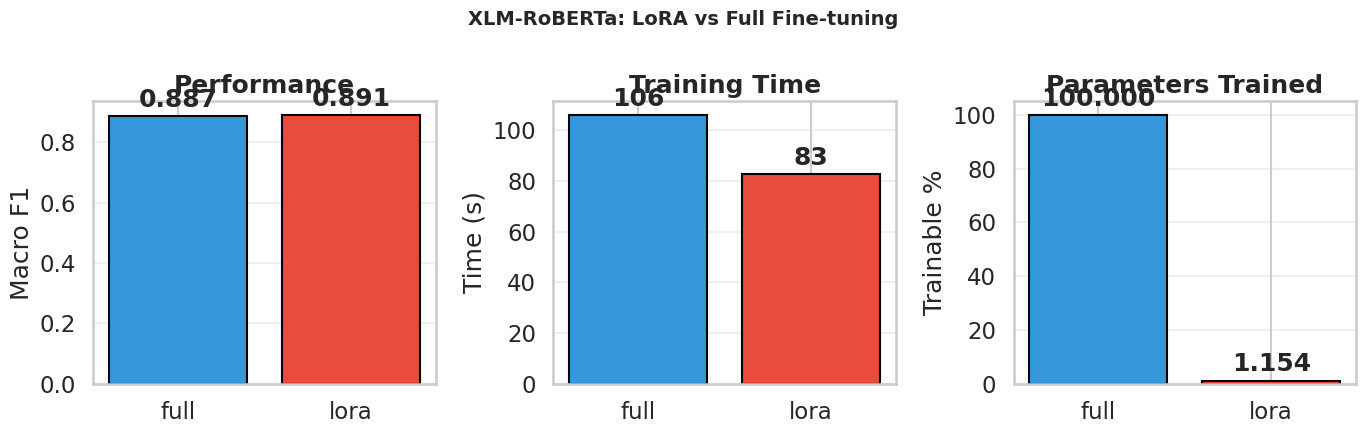


SELECTED FINE-TUNING METHOD: LORA
SELECTED BALANCING STRATEGY: WEIGHTED


In [10]:
# Fine-tuning method comparison: LoRA vs full

def run_finetuning_comparison(task_name: str = 'Sentiment', seed: int = 42) -> Dict[str, Any]:
    lbl_col = get_label_col(task_name)
    print(f"\n{'='*60}")
    print(f'FINE-TUNING COMPARISON: {task_name} (seed={seed})')
    print(f"{'='*60}")

    tr_texts = list(pooled['train'][text_col])
    tr_labels = [int(x) for x in pooled['train'][lbl_col]]
    va_texts  = list(pooled['validation'][text_col])
    va_labels = [int(x) for x in pooled['validation'][lbl_col]]
    te_texts  = list(pooled['test'][text_col])
    te_labels = [int(x) for x in pooled['test'][lbl_col]]

    use_weighted_loss = (SELECTED_BALANCING_STRATEGY == 'weighted')
    results = {}

    for method in FINETUNE_METHODS:
        print(f'\n>>> Method: {method.upper()}')
        set_seed(seed)

        tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True)
        use_lora  = (method == 'lora' and PEFT_AVAILABLE)
        start     = time.time()
        model     = (get_model_with_lora(MODEL_NAME, 2) if use_lora
                     else AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2, problem_type='single_label_classification'))
        model     = model.to(DEVICE)

        tr_p, tot_p = count_parameters(model)
        print(f'  Parameters: {tr_p:,} trainable / {tot_p:,} total ({100*tr_p/tot_p:.2f}%)')

        tr_ds = TextDataset(tr_texts, tr_labels, tokenizer, MAX_LEN)
        va_ds = TextDataset(va_texts, va_labels, tokenizer, MAX_LEN)
        te_ds = TextDataset(te_texts, te_labels, tokenizer, MAX_LEN)

        cw   = compute_class_weight('balanced', classes=np.array([0, 1]), y=np.array(tr_labels)) if use_weighted_loss else None
        ckpt = OUT_DIR / f'finetune_{method}_{task_name.lower()}_seed{seed}'
        args = get_training_args(str(ckpt), seed, use_lora=use_lora)
        if use_lora:
            args.per_device_train_batch_size = min(32, BATCH_SIZE_TRAIN * 2)
            args.per_device_eval_batch_size  = min(64, BATCH_SIZE_EVAL  * 2)

        history = TrainingHistoryCallback()
        trainer = get_trainer(
            model=model, args=args, train_dataset=tr_ds, eval_dataset=va_ds,
            tokenizer=tokenizer, class_weights=cw, use_weighted_loss=use_weighted_loss,
            callbacks=[EarlyStoppingCallback(early_stopping_patience=EARLY_STOPPING_PATIENCE), history],
        )
        trainer.train()
        training_time = time.time() - start

        pred      = trainer.predict(te_ds)
        y_pred    = np.argmax(pred.predictions, axis=-1)
        y_true    = np.array(te_labels)
        pcf1      = f1_score(y_true, y_pred, average=None, zero_division=0, labels=[0, 1])

        metrics = {
            'method': method,
            'trainable_params': tr_p,
            'total_params': tot_p,
            'trainable_pct': 100 * tr_p / tot_p,
            'training_time_sec': training_time,
            'accuracy':  float(accuracy_score(y_true, y_pred)),
            'macro_f1':  float(f1_score(y_true, y_pred, average='macro', zero_division=0)),
            'class_0_f1': float(pcf1[0]),
            'class_1_f1': float(pcf1[1]),
            'macro_precision': float(precision_score(y_true, y_pred, average='macro', zero_division=0)),
            'macro_recall':    float(recall_score(y_true, y_pred, average='macro', zero_division=0)),
        }
        results[method] = metrics
        print(f'  -> Macro F1: {metrics["macro_f1"]:.4f}  Class0: {metrics["class_0_f1"]:.4f}  Class1: {metrics["class_1_f1"]:.4f}')
        print(f'  -> Time: {training_time:.1f}s')

        save_p = OUT_DIR / f'{MODEL_LABEL.lower().replace("-","")}_{method}_{task_name.lower()}_seed{seed}'
        save_p.mkdir(parents=True, exist_ok=True)
        model.save_pretrained(str(save_p))
        tokenizer.save_pretrained(str(save_p))

        del model, trainer
        if torch.cuda.is_available(): torch.cuda.empty_cache()

    return results


if len(FINETUNE_METHODS) > 1:
    finetuning_comparison = run_finetuning_comparison('Sentiment', seed=42)
    comparison_df = pd.DataFrame(list(finetuning_comparison.values()))
    print(f"\n{'='*60}\nFINE-TUNING COMPARISON RESULTS\n{'='*60}")
    print(comparison_df[['method', 'trainable_pct', 'training_time_sec', 'macro_f1', 'class_0_f1', 'class_1_f1']].to_string(index=False))

    full_f1 = finetuning_comparison['full']['macro_f1']
    lora_f1 = finetuning_comparison.get('lora', {}).get('macro_f1', 0)

    if lora_f1 >= full_f1 - 0.01:
        SELECTED_FINETUNE_METHOD = 'lora'
        print(f'\n>>> AUTO-SELECTED: LORA  (F1 within 1% of Full)')
    else:
        SELECTED_FINETUNE_METHOD = 'full'
        print(f'\n>>> AUTO-SELECTED: FULL  (Full F1 > LoRA F1 by >1%)')

    fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
    methods = list(finetuning_comparison.keys())
    colors  = ['#3498db', '#e74c3c'][:len(methods)]
    for ax, (vals, ylabel, title) in zip(axes, [
        ([finetuning_comparison[m]['macro_f1']           for m in methods], 'Macro F1',       'Performance'),
        ([finetuning_comparison[m]['training_time_sec']  for m in methods], 'Time (s)',       'Training Time'),
        ([finetuning_comparison[m]['trainable_pct']      for m in methods], 'Trainable %',   'Parameters Trained'),
    ]):
        bars = ax.bar(methods, vals, color=colors, edgecolor='black')
        ax.bar_label(bars, fmt='%.3f' if ylabel != 'Time (s)' else '%.0f', padding=3, fontweight='bold')
        ax.set_ylabel(ylabel); ax.set_title(title, fontweight='bold'); ax.grid(axis='y', alpha=0.3)
    plt.suptitle(f'{MODEL_LABEL}: LoRA vs Full Fine-tuning', fontweight='bold', fontsize=14)
    plt.tight_layout()
    plt.savefig(OUT_DIR / 'finetuning_method_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    comparison_df.to_csv(OUT_DIR / 'finetuning_method_comparison.csv', index=False)
else:
    SELECTED_FINETUNE_METHOD = 'full'
    print('Only full fine-tuning available (PEFT not installed)')

print(f"\n{'='*60}")
print(f'SELECTED FINE-TUNING METHOD: {SELECTED_FINETUNE_METHOD.upper()}')
print(f'SELECTED BALANCING STRATEGY: {SELECTED_BALANCING_STRATEGY.upper()}')
print(f"{'='*60}")

In [14]:
# Unified training helpers

use_weighted = (SELECTED_BALANCING_STRATEGY == 'weighted')
use_focal    = (SELECTED_BALANCING_STRATEGY == 'focal')

SAVE_TOTAL_LIMIT = 2


def load_model_with_selected_method(model_name: str, num_labels: int = 2):
    if SELECTED_FINETUNE_METHOD == 'lora' and PEFT_AVAILABLE:
        return get_model_with_lora(model_name, num_labels)
    return AutoModelForSequenceClassification.from_pretrained(
        model_name, num_labels=num_labels, problem_type='single_label_classification'
    )


def get_optimized_training_args(output_dir: str, seed: int) -> TrainingArguments:
    use_lora = (SELECTED_FINETUNE_METHOD == 'lora' and PEFT_AVAILABLE)
    args = get_training_args(output_dir, seed, use_lora=use_lora)
    if use_lora:
        args.per_device_train_batch_size = min(32, BATCH_SIZE_TRAIN * 2)
        args.per_device_eval_batch_size  = min(64, BATCH_SIZE_EVAL  * 2)
        args.num_train_epochs            = max(3, NUM_EPOCHS - 1)
    return args


def _save_model_snapshot(trainer, tokenizer, save_path: Path):
    save_path.mkdir(parents=True, exist_ok=True)
    trainer.model.save_pretrained(str(save_path))
    tokenizer.save_pretrained(str(save_path))


# Task runner functions

def run_pooled_for_task(task_name: str, seed: int, save_plots: bool = True) -> Dict[str, Any]:
    """Pooled training: all varieties combined."""
    set_seed(seed)
    lbl_col = get_label_col(task_name)
    print(f'\n  [{task_name}] Pooled training, seed={seed}')

    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True)
    model     = load_model_with_selected_method(MODEL_NAME, num_labels=2).to(DEVICE)

    tr_texts  = list(pooled['train'][text_col])
    tr_labels = [int(x) for x in pooled['train'][lbl_col]]
    va_texts  = list(pooled['validation'][text_col])
    va_labels = [int(x) for x in pooled['validation'][lbl_col]]
    te_texts  = list(pooled['test'][text_col])
    te_labels = [int(x) for x in pooled['test'][lbl_col]]

    tr_ds = TextDataset(tr_texts, tr_labels, tokenizer, MAX_LEN)
    va_ds = TextDataset(va_texts, va_labels, tokenizer, MAX_LEN)
    te_ds = TextDataset(te_texts, te_labels, tokenizer, MAX_LEN)

    cw     = compute_class_weight('balanced', classes=np.unique(tr_labels), y=np.array(tr_labels))
    ckpt_d = task_out_dir(task_name) / 'checkpoints' / f'pooled_seed{seed}'
    args   = get_optimized_training_args(str(ckpt_d), seed)
    args.save_total_limit = SAVE_TOTAL_LIMIT

    history = TrainingHistoryCallback()
    trainer = get_trainer(
        model=model, args=args, train_dataset=tr_ds, eval_dataset=va_ds,
        tokenizer=tokenizer, class_weights=cw,
        use_weighted_loss=use_weighted, use_focal_loss=use_focal,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=EARLY_STOPPING_PATIENCE), history],
    )
    trainer.train()

    t0 = time.time()
    pred = trainer.predict(te_ds)
    inf_time = time.time() - t0

    y_pred  = np.argmax(pred.predictions, axis=-1)
    y_probs = torch.softmax(torch.tensor(pred.predictions), dim=-1).numpy()[:, 1]
    y_true  = pred.label_ids
    cm      = confusion_matrix(y_true, y_pred)

    metrics = {
        'seed': seed, 'task': task_name,
        'accuracy':          float(accuracy_score(y_true, y_pred)),
        'macro_f1':          float(f1_score(y_true, y_pred, average='macro',    zero_division=0)),
        'macro_precision':   float(precision_score(y_true, y_pred, average='macro',    zero_division=0)),
        'macro_recall':      float(recall_score(y_true, y_pred, average='macro',    zero_division=0)),
        'weighted_f1':       float(f1_score(y_true, y_pred, average='weighted', zero_division=0)),
        'inference_time_sec': inf_time,
        'samples_per_sec':   len(te_ds) / inf_time if inf_time > 0 else 0,
    }
    try:
        metrics['roc_auc'] = float(roc_auc_score(y_true, y_probs))
    except Exception:
        metrics['roc_auc'] = np.nan

    final_dir = task_out_dir(task_name) / 'final_models' / f'{MODEL_LABEL.lower().replace("-","")}_{task_name.lower()}_pooled_seed{seed}'
    _save_model_snapshot(trainer, tokenizer, final_dir)

    if save_plots:
        plot_training_history(history, task_out_dir(task_name) / f'pooled_seed{seed}_history.png',
                              title_prefix=f'{MODEL_LABEL} {task_name} Pooled (seed={seed}) - ')
        plot_confusion_matrix(cm, task_out_dir(task_name) / f'pooled_seed{seed}_cm.png',
                              title=f'{MODEL_LABEL} {task_name} Pooled (seed={seed})')

    result = {**metrics, 'report': classification_report(y_true, y_pred, output_dict=True, zero_division=0),
              'cm': cm, 'y_true': y_true, 'y_pred': y_pred, 'y_probs': y_probs,
              'checkpoint_dir': str(ckpt_d), 'final_model_dir': str(final_dir)}

    del model, trainer
    if torch.cuda.is_available(): torch.cuda.empty_cache()
    print(f'    -> Macro F1: {metrics["macro_f1"]:.4f}  Accuracy: {metrics["accuracy"]:.4f}')
    return result


def run_cross_for_task(task_name: str, train_variety: str, seed: int, save_plots: bool = False) -> Dict[str, Any]:
    """Cross-variety training: train on one variety, test on all."""
    set_seed(seed)
    lbl_col = get_label_col(task_name)
    print(f'\n  [{task_name}] Cross training: {train_variety}, seed={seed}')

    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True)
    model     = load_model_with_selected_method(MODEL_NAME, num_labels=2).to(DEVICE)

    # Per-variety splits
    vs = {}
    for v in VARIETIES:
        vs[v] = {}
        for split in ['train', 'validation', 'test']:
            mask = [x == v for x in pooled[split][variety_col]]
            vs[v][split] = (
                [t for t, m in zip(pooled[split][text_col], mask) if m],
                [int(y) for y, m in zip(pooled[split][lbl_col], mask) if m],
            )

    tr_x, tr_y = vs[train_variety]['train']
    va_x, va_y = vs[train_variety]['validation']
    tr_ds = TextDataset(tr_x, tr_y, tokenizer, MAX_LEN)
    va_ds = TextDataset(va_x, va_y, tokenizer, MAX_LEN)

    cw     = compute_class_weight('balanced', classes=np.unique(tr_y), y=np.array(tr_y))
    ckpt_d = task_out_dir(task_name) / 'checkpoints' / f'cross_train-{train_variety}_seed{seed}'
    args   = get_optimized_training_args(str(ckpt_d), seed)
    args.save_total_limit = SAVE_TOTAL_LIMIT

    history = TrainingHistoryCallback()
    trainer = get_trainer(
        model=model, args=args, train_dataset=tr_ds, eval_dataset=va_ds,
        tokenizer=tokenizer, class_weights=cw,
        use_weighted_loss=use_weighted, use_focal_loss=use_focal,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=EARLY_STOPPING_PATIENCE), history],
    )
    trainer.train()

    out = {}
    for tv in VARIETIES:
        te_x, te_y = vs[tv]['test']
        te_ds = TextDataset(te_x, te_y, tokenizer, MAX_LEN)
        t0    = time.time()
        pred  = trainer.predict(te_ds)
        inf_t = time.time() - t0

        y_pred  = np.argmax(pred.predictions, axis=-1)
        y_probs = torch.softmax(torch.tensor(pred.predictions), dim=-1).numpy()[:, 1]
        y_true  = pred.label_ids
        cm      = confusion_matrix(y_true, y_pred)

        m = {
            'accuracy':          float(accuracy_score(y_true, y_pred)),
            'macro_f1':          float(f1_score(y_true, y_pred, average='macro',    zero_division=0)),
            'macro_precision':   float(precision_score(y_true, y_pred, average='macro',    zero_division=0)),
            'macro_recall':      float(recall_score(y_true, y_pred, average='macro',    zero_division=0)),
            'weighted_f1':       float(f1_score(y_true, y_pred, average='weighted', zero_division=0)),
            'inference_time_sec': inf_t,
            'samples_per_sec':   len(te_ds) / inf_t if inf_t > 0 else 0,
        }
        try:
            m['roc_auc'] = float(roc_auc_score(y_true, y_probs))
        except Exception:
            m['roc_auc'] = np.nan
        out[tv] = {**m, 'report': classification_report(y_true, y_pred, output_dict=True, zero_division=0),
                   'cm': cm, 'y_true': y_true, 'y_pred': y_pred, 'y_probs': y_probs}

    final_dir = task_out_dir(task_name) / 'final_models' / f'{MODEL_LABEL.lower().replace("-","")}_{task_name.lower()}_cross_train-{train_variety}_seed{seed}'
    _save_model_snapshot(trainer, tokenizer, final_dir)
    out['_meta'] = {'task': task_name, 'train_variety': train_variety, 'seed': seed,
                    'checkpoint_dir': str(ckpt_d), 'final_model_dir': str(final_dir)}

    del model, trainer
    if torch.cuda.is_available(): torch.cuda.empty_cache()
    return out


def run_combined_for_task(task_name: str, seed: int, save_plots: bool = False) -> Dict[str, Any]:
    """Combined training: train on all varieties, evaluate per variety."""
    set_seed(seed)
    lbl_col = get_label_col(task_name)
    print(f'\n  [{task_name}] Combined training, seed={seed}')

    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True)
    model     = load_model_with_selected_method(MODEL_NAME, num_labels=2).to(DEVICE)

    tr_x = list(pooled['train'][text_col])
    tr_y = [int(x) for x in pooled['train'][lbl_col]]
    va_x = list(pooled['validation'][text_col])
    va_y = [int(x) for x in pooled['validation'][lbl_col]]

    tr_ds = TextDataset(tr_x, tr_y, tokenizer, MAX_LEN)
    va_ds = TextDataset(va_x, va_y, tokenizer, MAX_LEN)

    cw     = compute_class_weight('balanced', classes=np.unique(tr_y), y=np.array(tr_y))
    ckpt_d = task_out_dir(task_name) / 'checkpoints' / f'combined_seed{seed}'
    args   = get_optimized_training_args(str(ckpt_d), seed)
    args.save_total_limit = SAVE_TOTAL_LIMIT

    history = TrainingHistoryCallback()
    trainer = get_trainer(
        model=model, args=args, train_dataset=tr_ds, eval_dataset=va_ds,
        tokenizer=tokenizer, class_weights=cw,
        use_weighted_loss=use_weighted, use_focal_loss=use_focal,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=EARLY_STOPPING_PATIENCE), history],
    )
    trainer.train()

    out = {}
    for tv in VARIETIES:
        mask  = [x == tv for x in pooled['test'][variety_col]]
        te_x  = [t for t, m in zip(pooled['test'][text_col], mask) if m]
        te_y  = [int(y) for y, m in zip(pooled['test'][lbl_col], mask) if m]
        te_ds = TextDataset(te_x, te_y, tokenizer, MAX_LEN)
        t0    = time.time()
        pred  = trainer.predict(te_ds)
        inf_t = time.time() - t0

        y_pred  = np.argmax(pred.predictions, axis=-1)
        y_probs = torch.softmax(torch.tensor(pred.predictions), dim=-1).numpy()[:, 1]
        y_true  = pred.label_ids
        cm      = confusion_matrix(y_true, y_pred)

        m = {
            'accuracy':          float(accuracy_score(y_true, y_pred)),
            'macro_f1':          float(f1_score(y_true, y_pred, average='macro',    zero_division=0)),
            'macro_precision':   float(precision_score(y_true, y_pred, average='macro',    zero_division=0)),
            'macro_recall':      float(recall_score(y_true, y_pred, average='macro',    zero_division=0)),
            'weighted_f1':       float(f1_score(y_true, y_pred, average='weighted', zero_division=0)),
            'inference_time_sec': inf_t,
            'samples_per_sec':   len(te_ds) / inf_t if inf_t > 0 else 0,
        }
        try:
            m['roc_auc'] = float(roc_auc_score(y_true, y_probs))
        except Exception:
            m['roc_auc'] = np.nan
        out[tv] = {**m, 'report': classification_report(y_true, y_pred, output_dict=True, zero_division=0),
                   'cm': cm, 'y_true': y_true, 'y_pred': y_pred, 'y_probs': y_probs}

    final_dir = task_out_dir(task_name) / 'final_models' / f'{MODEL_LABEL.lower().replace("-","")}_{task_name.lower()}_combined_seed{seed}'
    _save_model_snapshot(trainer, tokenizer, final_dir)
    out['_meta'] = {'task': task_name, 'seed': seed, 'checkpoint_dir': str(ckpt_d), 'final_model_dir': str(final_dir)}

    del model, trainer
    if torch.cuda.is_available(): torch.cuda.empty_cache()
    return out


print('Loaded: run_pooled_for_task, run_cross_for_task, run_combined_for_task')
print(f'Task:      {TASKS}')
print(f'Seeds:     {SEEDS}')
print(f'Varieties: {VARIETIES}')

Loaded: run_pooled_for_task, run_cross_for_task, run_combined_for_task
Task:      ['Sentiment']
Seeds:     [42, 123, 456]
Varieties: ['en-AU', 'en-IN', 'en-UK']


In [15]:
# Comprehensive metrics helpers

def compute_mcc(y_true, y_pred):
    return matthews_corrcoef(y_true, y_pred)


def compute_prediction_confidence(logits: np.ndarray) -> Dict[str, float]:
    probs     = torch.softmax(torch.tensor(logits), dim=-1).numpy()
    max_probs = np.max(probs, axis=1)
    entropy   = -np.sum(probs * np.log(probs + 1e-10), axis=1)
    return {
        'mean_confidence':  float(np.mean(max_probs)),
        'confidence_std':   float(np.std(max_probs)),
        'min_confidence':   float(np.min(max_probs)),
        'max_confidence':   float(np.max(max_probs)),
        'mean_entropy':     float(np.mean(entropy)),
        'entropy_std':      float(np.std(entropy)),
    }


def compute_expected_calibration_error(y_true: np.ndarray, y_probs: np.ndarray, n_bins: int = 10) -> Dict[str, Any]:
    bin_boundaries = np.linspace(0, 1, n_bins + 1)
    confidences    = np.max(y_probs, axis=1)
    predictions    = np.argmax(y_probs, axis=1)
    accuracies_arr = predictions == y_true
    ece, bin_data  = 0.0, []
    for lo, hi in zip(bin_boundaries[:-1], bin_boundaries[1:]):
        in_bin = (confidences > lo) & (confidences <= hi)
        if np.mean(in_bin) > 0:
            avg_conf = np.mean(confidences[in_bin])
            avg_acc  = np.mean(accuracies_arr[in_bin])
            ece     += abs(avg_acc - avg_conf) * np.mean(in_bin)
            bin_data.append({'bin_lower': lo, 'bin_upper': hi, 'avg_confidence': avg_conf,
                             'avg_accuracy': avg_acc, 'count': int(np.sum(in_bin))})
    return {'ece': float(ece), 'bin_data': bin_data, 'n_bins': n_bins}


def compute_comprehensive_metrics(y_true: np.ndarray, y_pred: np.ndarray, y_probs: np.ndarray) -> Dict[str, Any]:
    pcf1   = f1_score(y_true, y_pred, average=None, zero_division=0, labels=[0, 1])
    pc_pre = precision_score(y_true, y_pred, average=None, zero_division=0, labels=[0, 1])
    pc_rec = recall_score(y_true, y_pred, average=None, zero_division=0, labels=[0, 1])
    metrics = {
        'accuracy':           float(accuracy_score(y_true, y_pred)),
        'macro_f1':           float(f1_score(y_true, y_pred, average='macro',    zero_division=0)),
        'weighted_f1':        float(f1_score(y_true, y_pred, average='weighted', zero_division=0)),
        'mcc':                float(compute_mcc(y_true, y_pred)),
        'class_0_f1':         float(pcf1[0]),   'class_1_f1':         float(pcf1[1]),
        'class_0_precision':  float(pc_pre[0]), 'class_1_precision':  float(pc_pre[1]),
        'class_0_recall':     float(pc_rec[0]), 'class_1_recall':     float(pc_rec[1]),
        'calibration':        compute_expected_calibration_error(y_true, y_probs),
        'confidence':         compute_prediction_confidence(np.log(y_probs + 1e-10)),
    }
    try:
        if len(np.unique(y_true)) == 2:
            metrics['roc_auc']      = float(roc_auc_score(y_true, y_probs[:, 1]))
            metrics['avg_precision']= float(average_precision_score(y_true, y_probs[:, 1]))
    except Exception:
        pass
    return metrics


print('Comprehensive metric helpers loaded.')

Comprehensive metric helpers loaded.


## Run All Experiments (Sentiment Only)



RUNNING FULL PIPELINE FOR TASK: SENTIMENT

>>> Pooled Training

  [Sentiment] Pooled training, seed=42


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.bias                | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
classifier.dense.bias       | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.out_proj.weight  | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


  Trainable: 3,246,338 / 281,291,524 (1.15%)
  Using WeightedTrainer with class weights


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Macro Precision,Macro Recall,Weighted F1,Weighted Precision,Weighted Recall,Class 0 F1,Class 1 F1,Roc Auc,Avg Precision
1,0.973574,0.343115,0.897764,0.897712,0.900316,0.898713,0.897661,0.901167,0.897764,0.895425,0.900000,0.919220,0.874797
2,0.663725,0.302331,0.884984,0.884559,0.894751,0.886785,0.884402,0.896270,0.884984,0.877551,0.891566,0.969751,0.975960
3,0.613418,0.191034,0.932907,0.932863,0.932944,0.932802,0.932902,0.932915,0.932907,0.934579,0.931148,0.977083,0.980284
4,0.493223,0.207653,0.923323,0.923322,0.923609,0.923713,0.923327,0.924011,0.923323,0.923567,0.923077,0.973877,0.977464


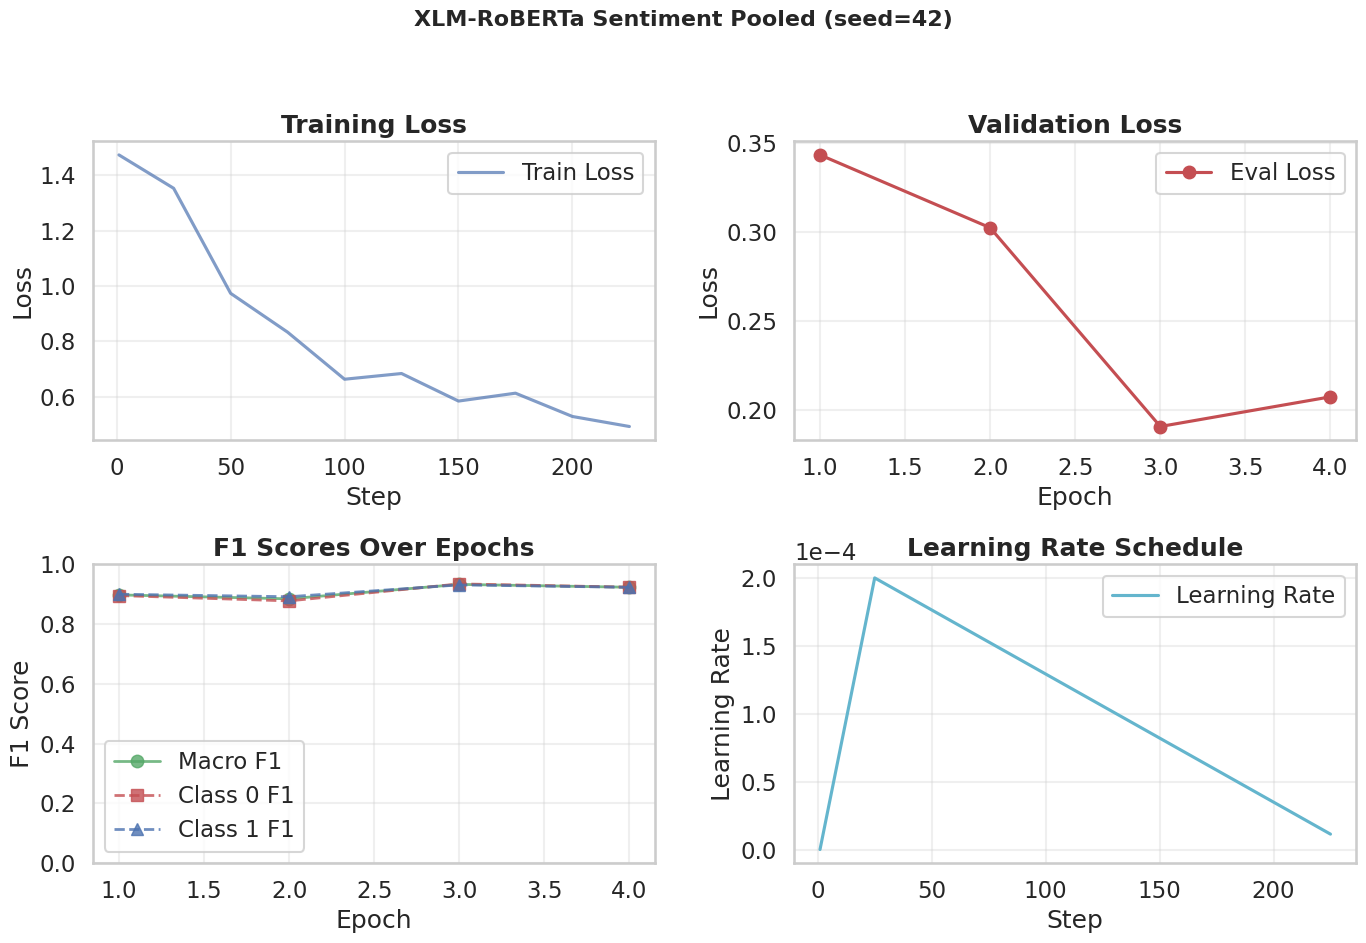

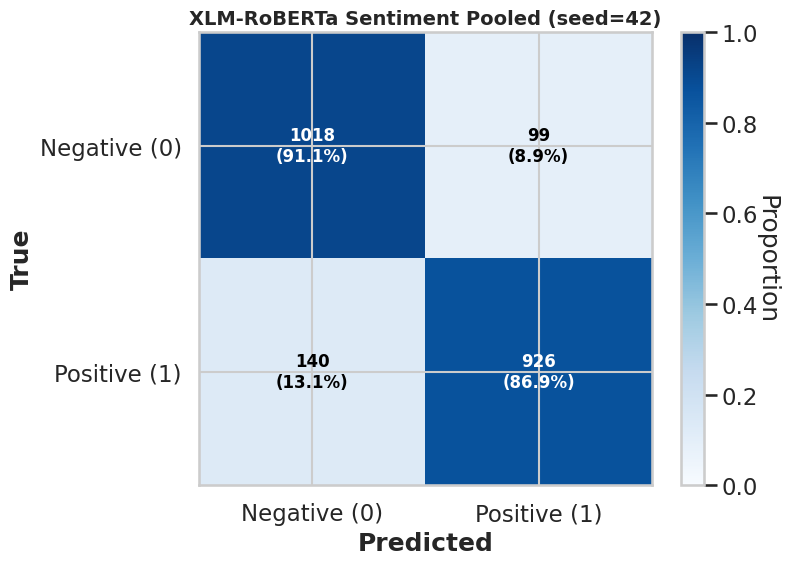

    -> Macro F1: 0.8903  Accuracy: 0.8905

  [Sentiment] Pooled training, seed=123


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.bias                | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
classifier.dense.bias       | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.out_proj.weight  | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


  Trainable: 3,246,338 / 281,291,524 (1.15%)
  Using WeightedTrainer with class weights


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Macro Precision,Macro Recall,Weighted F1,Weighted Precision,Weighted Recall,Class 0 F1,Class 1 F1,Roc Auc,Avg Precision
1,0.856431,0.359843,0.900958,0.900942,0.900927,0.901123,0.900971,0.901148,0.900958,0.902208,0.899676,0.954024,0.956227
2,0.679396,0.239688,0.904153,0.904129,0.905958,0.904963,0.904095,0.906701,0.904153,0.902597,0.905660,0.969853,0.974339
3,0.560098,0.222442,0.910543,0.910469,0.914078,0.911642,0.910412,0.915068,0.910543,0.907895,0.913043,0.973775,0.977012
4,0.471138,0.204878,0.932907,0.932896,0.932876,0.933088,0.932916,0.933095,0.932907,0.933754,0.932039,0.971487,0.975462


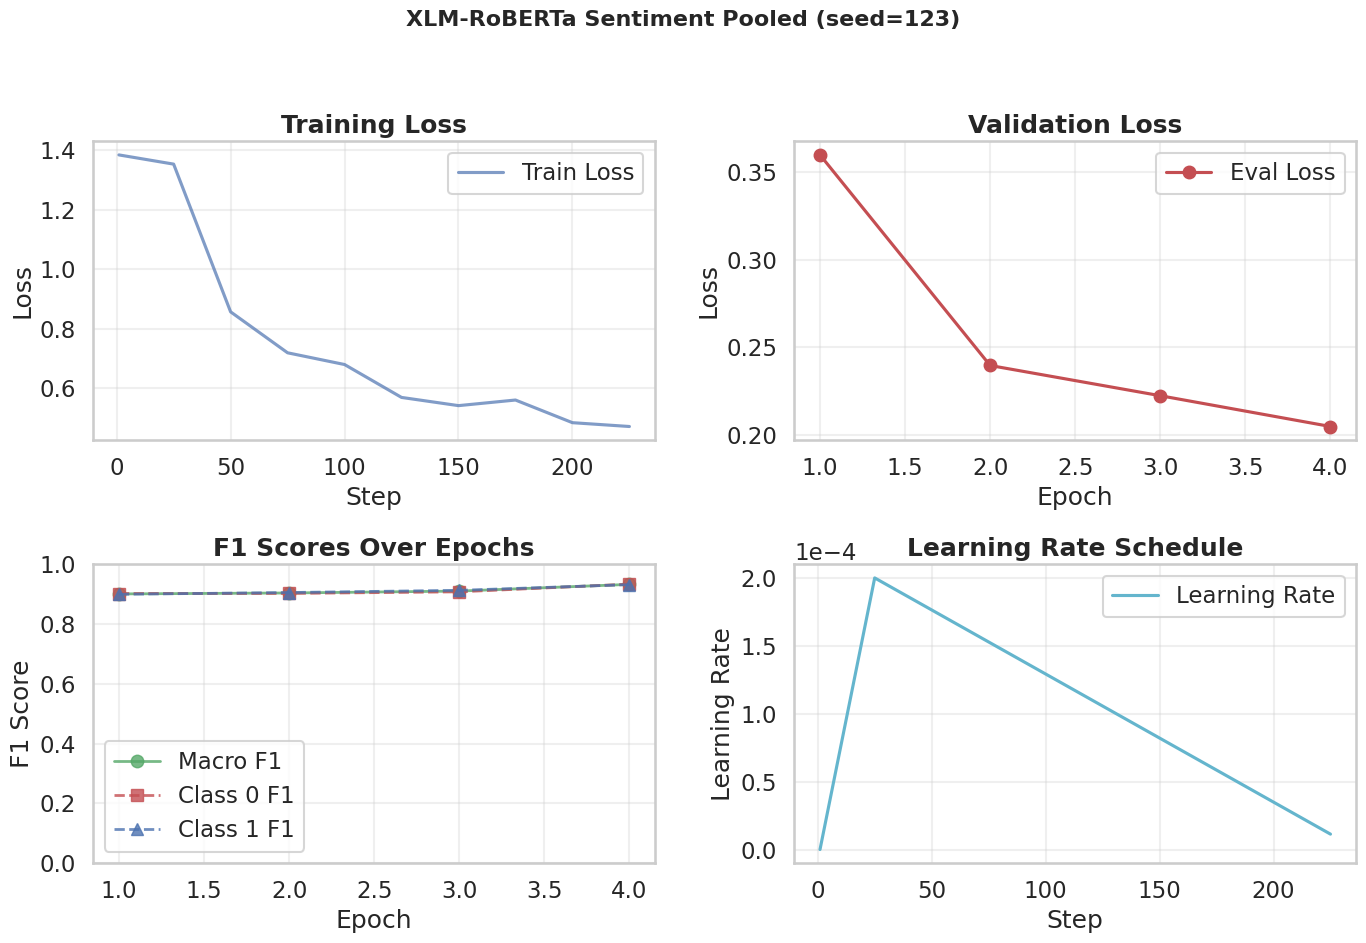

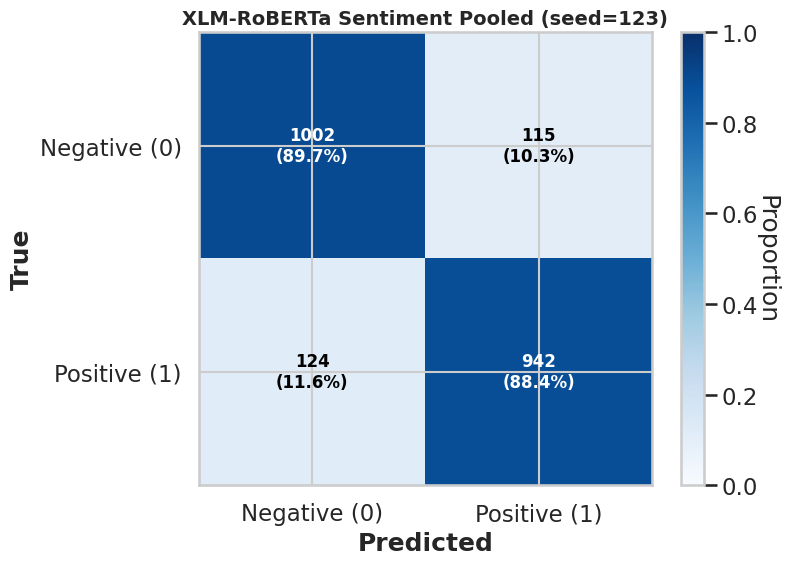

    -> Macro F1: 0.8904  Accuracy: 0.8905

  [Sentiment] Pooled training, seed=456


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.bias                | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
classifier.dense.bias       | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.out_proj.weight  | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


  Trainable: 3,246,338 / 281,291,524 (1.15%)
  Using WeightedTrainer with class weights


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Macro Precision,Macro Recall,Weighted F1,Weighted Precision,Weighted Recall,Class 0 F1,Class 1 F1,Roc Auc,Avg Precision
1,0.818756,0.241984,0.916933,0.916830,0.917356,0.916605,0.916896,0.917158,0.916933,0.919753,0.913907,0.949775,0.965060
2,0.703969,0.229643,0.916933,0.916789,0.917794,0.916462,0.916867,0.917477,0.916933,0.920245,0.913333,0.963542,0.972105
3,0.568141,0.193612,0.942492,0.942477,0.942425,0.942606,0.942498,0.942581,0.942492,0.943396,0.941558,0.974857,0.979345
4,0.472029,0.208971,0.936102,0.936070,0.936070,0.936070,0.936102,0.936102,0.936102,0.937500,0.934641,0.970833,0.976753


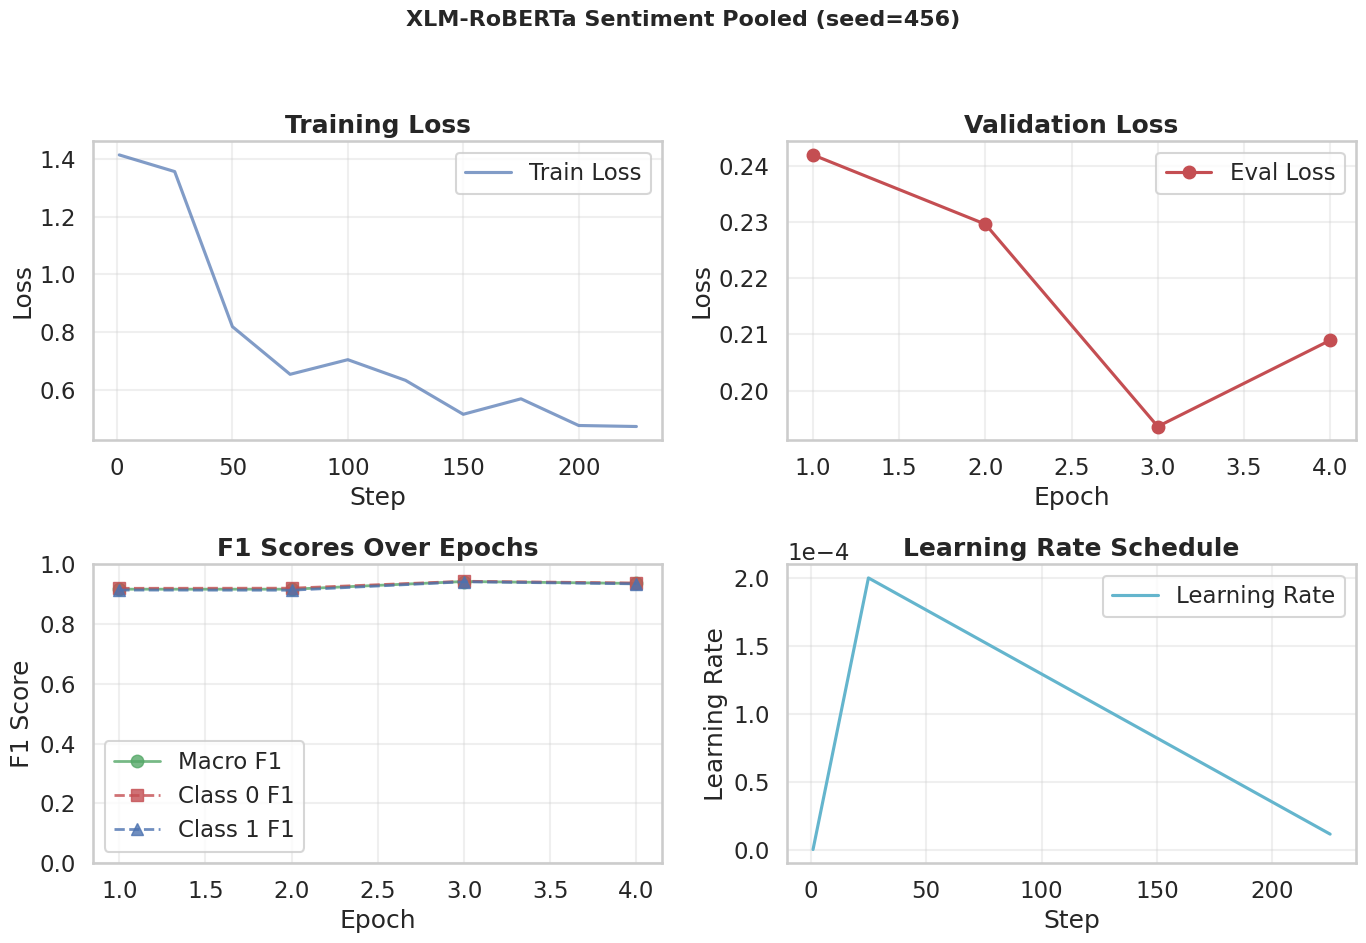

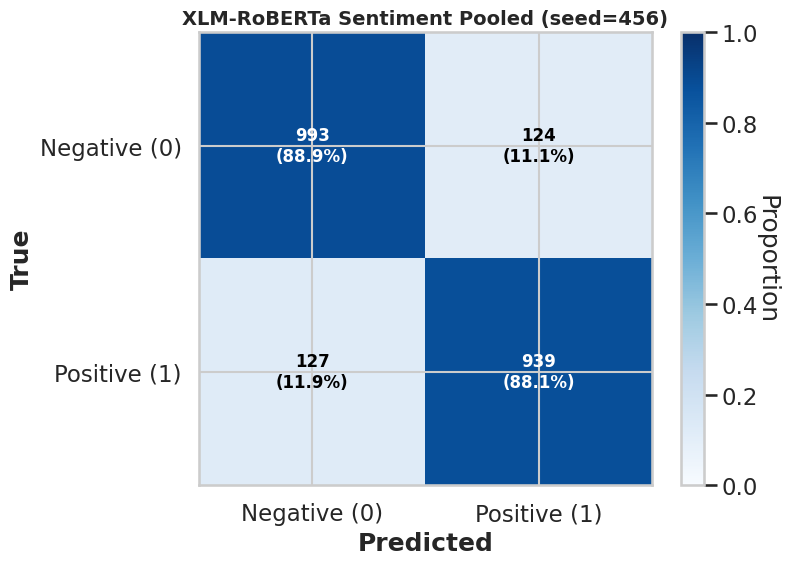

    -> Macro F1: 0.8850  Accuracy: 0.8850

  Pooled Results Summary:
    Mean Macro F1: 0.8886 (+/- 0.0031)

>>> Cross-Variety Training

  [Sentiment] Cross training: en-AU, seed=42


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.bias                | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
classifier.dense.bias       | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.out_proj.weight  | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Trainable: 3,246,338 / 281,291,524 (1.15%)


warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


...

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.bias                | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
classifier.dense.bias       | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.out_proj.weight  | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


  Trainable: 3,246,338 / 281,291,524 (1.15%)
  Using WeightedTrainer with class weights


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Macro Precision,Macro Recall,Weighted F1,Weighted Precision,Weighted Recall,Class 0 F1,Class 1 F1,Roc Auc,Avg Precision
1,0.818756,0.241984,0.916933,0.916830,0.917356,0.916605,0.916896,0.917158,0.916933,0.919753,0.913907,0.949775,0.965060
2,0.703969,0.229643,0.916933,0.916789,0.917794,0.916462,0.916867,0.917477,0.916933,0.920245,0.913333,0.963542,0.972105
3,0.568141,0.193612,0.942492,0.942477,0.942425,0.942606,0.942498,0.942581,0.942492,0.943396,0.941558,0.974857,0.979345
4,0.472029,0.208971,0.936102,0.936070,0.936070,0.936070,0.936102,0.936102,0.936102,0.937500,0.934641,0.970833,0.976753



  Combined Results by Variety:
    en-AU: F1=0.8844
    en-IN: F1=0.8481
    en-UK: F1=0.9390

  Saved all results to: /scratch/HS400/outputs_xlmroberta/sentiment

ALL EXPERIMENTS COMPLETED!


In [ ]:
# Run full pipeline: pooled -> cross-variety -> combined (sentiment only)
all_task_results = {}

for task_name in TASKS:  # ['Sentiment']
    print(f"\n{'='*90}")
    print(f'RUNNING FULL PIPELINE FOR TASK: {task_name.upper()}')
    print(f"{'='*90}")

    # Pooled
    print('\n>>> Pooled Training')
    task_dir = task_out_dir(task_name)
    if (task_dir / 'pooled_results.pkl').exists():
        with open(task_dir / 'pooled_results.pkl', 'rb') as f:
            pooled_results_task = pickle.load(f)
        print(f"  Loaded pooled results from cache")
    else:
        pooled_results_task = [run_pooled_for_task(task_name, s, save_plots=True) for s in SEEDS]
    pooled_df_task = pd.DataFrame([{
        'seed': r['seed'], 'accuracy': r['accuracy'],
        'macro_f1': r['macro_f1'], 'macro_precision': r['macro_precision'],
        'macro_recall': r['macro_recall'], 'weighted_f1': r['weighted_f1'],
        'roc_auc': r.get('roc_auc', np.nan),
        'inference_time_sec': r.get('inference_time_sec', np.nan),
        'samples_per_sec': r.get('samples_per_sec', np.nan),
        'checkpoint_dir': r['checkpoint_dir'], 'final_model_dir': r['final_model_dir'],
    } for r in pooled_results_task])

    print(f'\n  Pooled Results Summary:')
    print(f'    Mean Macro F1: {pooled_df_task["macro_f1"].mean():.4f} (+/- {pooled_df_task["macro_f1"].std():.4f})')

    # Cross-variety
    print('\n>>> Cross-Variety Training')
    if (task_dir / 'cross_raw_results.pkl').exists():
        with open(task_dir / 'cross_raw_results.pkl', 'rb') as f:
            cross_raw = pickle.load(f)
        print(f"  Loaded cross-variety results from cache")
    else:
        cross_raw = {}
        for tr in VARIETIES:
            for s in SEEDS:
                cross_raw[(tr, s)] = run_cross_for_task(task_name, tr, s, save_plots=False)

    cross_rows = []
    for tr in VARIETIES:
        for te in VARIETIES:
            metrics = [cross_raw[(tr, s)][te] for s in SEEDS]
            row = {'train_variety': tr, 'test_variety': te, 'route': f'{tr}\u2192{te}'}
            for m in ['accuracy', 'macro_f1', 'macro_precision', 'macro_recall', 'weighted_f1', 'roc_auc', 'inference_time_sec', 'samples_per_sec']:
                vals = [met.get(m, np.nan) for met in metrics]
                row[f'{m}_mean'] = float(np.nanmean(vals))
                row[f'{m}_std']  = float(np.nanstd(vals))
            cross_rows.append(row)
    cross_df_task = pd.DataFrame(cross_rows)

    best_route  = cross_df_task.sort_values('macro_f1_mean', ascending=False).iloc[0]
    worst_route = cross_df_task.sort_values('macro_f1_mean', ascending=True).iloc[0]
    print(f'\n  Best route:  {best_route["route"]}  (F1={best_route["macro_f1_mean"]:.4f})')
    print(f'  Worst route: {worst_route["route"]} (F1={worst_route["macro_f1_mean"]:.4f})')

    # Combined
    print('\n>>> Combined Training')
    if (task_dir / 'combined_raw_results.pkl').exists():
        with open(task_dir / 'combined_raw_results.pkl', 'rb') as f:
            combined_raw = pickle.load(f)
        print(f"  Loaded combined results from cache")
    else:
        combined_raw = {s: run_combined_for_task(task_name, s, save_plots=False) for s in SEEDS}
    combined_rows = []
    for tv in VARIETIES:
        metrics = [combined_raw[s][tv] for s in SEEDS]
        row = {'train_setup': 'combined_all_varieties', 'test_variety': tv}
        for m in ['accuracy', 'macro_f1', 'macro_precision', 'macro_recall', 'weighted_f1', 'roc_auc', 'inference_time_sec', 'samples_per_sec']:
            vals = [met.get(m, np.nan) for met in metrics]
            row[f'{m}_mean'] = float(np.nanmean(vals))
            row[f'{m}_std']  = float(np.nanstd(vals))
        combined_rows.append(row)
    combined_df_task = pd.DataFrame(combined_rows)

    print('\n  Combined Results by Variety:')
    for _, row in combined_df_task.iterrows():
        print(f'    {row["test_variety"]}: F1={row["macro_f1_mean"]:.4f}')

    # Save
    pooled_df_task.to_csv(task_dir / 'pooled_results.csv', index=False)
    cross_df_task.to_csv(task_dir / 'cross_variety_results.csv', index=False)
    combined_df_task.to_csv(task_dir / 'combined_results.csv', index=False)

    with open(task_dir / 'pooled_results.pkl', 'wb') as f:     pickle.dump(pooled_results_task, f)
    with open(task_dir / 'cross_raw_results.pkl', 'wb') as f:  pickle.dump(cross_raw, f)
    with open(task_dir / 'combined_raw_results.pkl', 'wb') as f: pickle.dump(combined_raw, f)

    all_task_results[task_name] = {
        'pooled_results': pooled_results_task, 'pooled_df': pooled_df_task,
        'cross_raw': cross_raw,   'cross_df': cross_df_task,
        'combined_raw': combined_raw, 'combined_df': combined_df_task,
    }
    print(f'\n  Saved all results to: {task_dir}')

with open(OUT_DIR / 'all_task_results.pkl', 'wb') as f:
    pickle.dump(all_task_results, f)

print(f"\n{'='*90}\nALL EXPERIMENTS COMPLETED!\n{'='*90}")


------------------------------------------------------------------------------------------
COMPREHENSIVE ANALYSIS: SENTIMENT
------------------------------------------------------------------------------------------

  POOLED TRAINING:
    Mean Macro F1: 0.8886 (+/- 0.0031)
    Mean Accuracy: 0.8887
    Mean ROC-AUC:  0.9552

  CROSS-VARIETY:
    Best route:  en-IN→en-UK  F1=0.9323
    Worst route: en-AU→en-IN F1=0.8071
    Same-variety avg F1:  0.8859
    Cross-variety avg F1: 0.8694
    Transfer gap:         0.0165

  COMBINED VS SINGLE-ROUTE:
test_variety  combined_f1  single_avg_f1  best_single_f1  delta_vs_avg
       en-AU     0.884352       0.874468        0.885528      0.009884
       en-IN     0.848087       0.821964        0.844256      0.026123
       en-UK     0.938977       0.928260        0.932266      0.010717


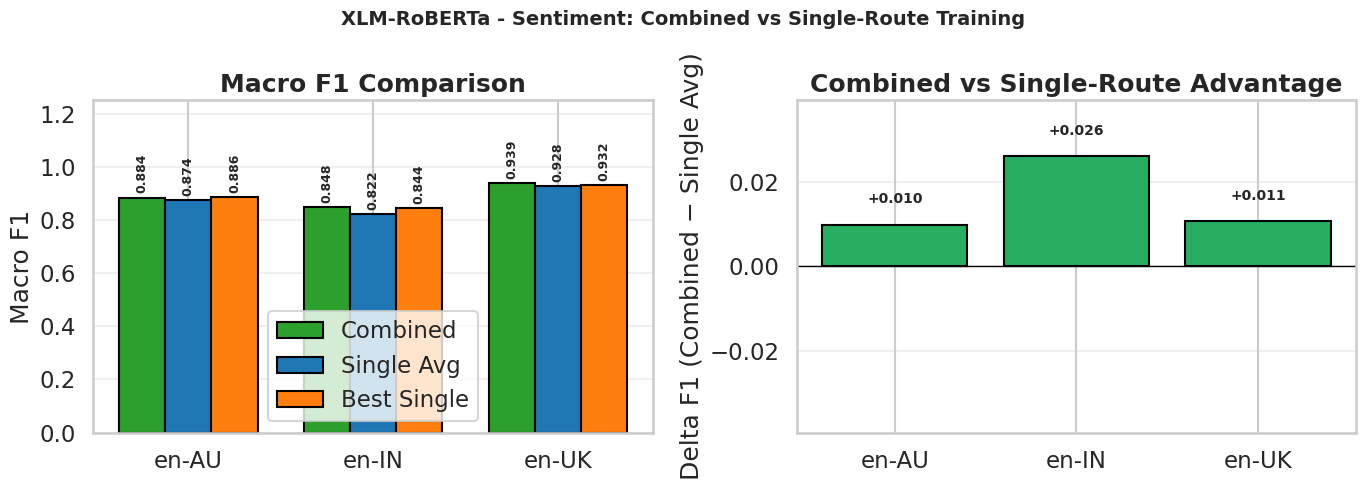

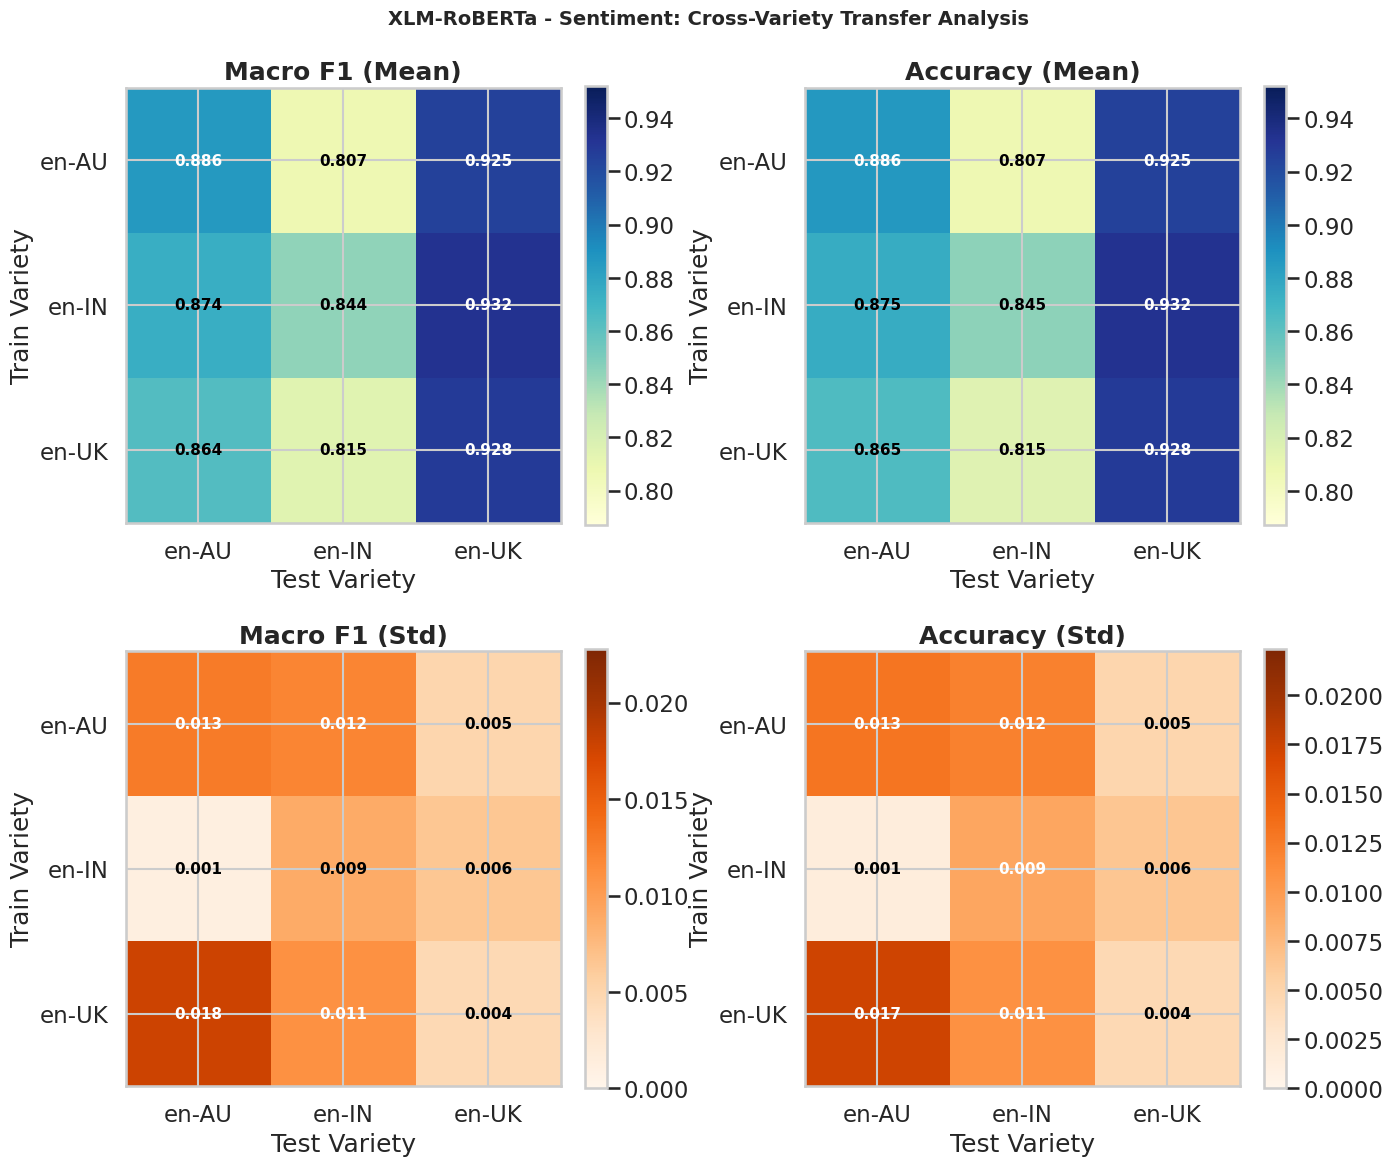

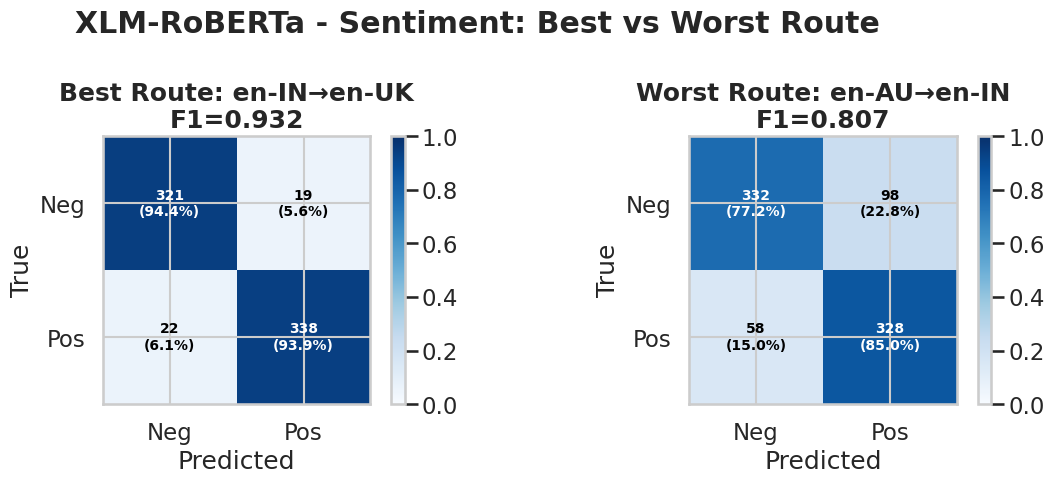


ANALYSIS COMPLETED!


In [17]:
# Comprehensive analysis and visualizations

def _best_worst(df):
    return df.sort_values('macro_f1_mean', ascending=False).iloc[0], df.sort_values('macro_f1_mean', ascending=True).iloc[0]


for task_name in TASKS:
    if task_name not in all_task_results:
        continue

    print(f"\n{'-'*90}\nCOMPREHENSIVE ANALYSIS: {task_name.upper()}\n{'-'*90}")

    pooled_df_task   = all_task_results[task_name]['pooled_df']
    cross_df_task    = all_task_results[task_name]['cross_df']
    combined_df_task = all_task_results[task_name]['combined_df']
    cross_raw        = all_task_results[task_name]['cross_raw']
    combined_raw     = all_task_results[task_name]['combined_raw']
    task_dir         = task_out_dir(task_name)

    # Pooled summary
    print(f'\n  POOLED TRAINING:')
    print(f'    Mean Macro F1: {pooled_df_task["macro_f1"].mean():.4f} (+/- {pooled_df_task["macro_f1"].std():.4f})')
    print(f'    Mean Accuracy: {pooled_df_task["accuracy"].mean():.4f}')
    print(f'    Mean ROC-AUC:  {pooled_df_task["roc_auc"].mean():.4f}')

    # Cross-variety summary
    b, w = _best_worst(cross_df_task)
    same_v = cross_df_task[cross_df_task['train_variety'] == cross_df_task['test_variety']]
    diff_v = cross_df_task[cross_df_task['train_variety'] != cross_df_task['test_variety']]
    print(f'\n  CROSS-VARIETY:')
    print(f'    Best route:  {b["route"]}  F1={b["macro_f1_mean"]:.4f}')
    print(f'    Worst route: {w["route"]} F1={w["macro_f1_mean"]:.4f}')
    print(f'    Same-variety avg F1:  {same_v["macro_f1_mean"].mean():.4f}')
    print(f'    Cross-variety avg F1: {diff_v["macro_f1_mean"].mean():.4f}')
    print(f'    Transfer gap:         {same_v["macro_f1_mean"].mean() - diff_v["macro_f1_mean"].mean():.4f}')

    # Combined vs single
    print(f'\n  COMBINED VS SINGLE-ROUTE:')
    cmp_rows = []
    for tv in VARIETIES:
        combined_f1   = float(combined_df_task[combined_df_task.test_variety == tv]['macro_f1_mean'].iloc[0])
        combined_acc  = float(combined_df_task[combined_df_task.test_variety == tv]['accuracy_mean'].iloc[0])
        single_avg_f1 = float(cross_df_task[cross_df_task.test_variety == tv]['macro_f1_mean'].mean())
        single_avg_acc= float(cross_df_task[cross_df_task.test_variety == tv]['accuracy_mean'].mean())
        best_single   = cross_df_task[cross_df_task.test_variety == tv].sort_values('macro_f1_mean', ascending=False).iloc[0]
        cmp_rows.append({
            'test_variety': tv,
            'combined_f1': combined_f1, 'combined_acc': combined_acc,
            'single_avg_f1': single_avg_f1, 'single_avg_acc': single_avg_acc,
            'best_single_f1': best_single['macro_f1_mean'],
            'best_single_route': best_single['route'],
            'delta_vs_avg':  combined_f1 - single_avg_f1,
            'delta_vs_best': combined_f1 - best_single['macro_f1_mean'],
        })
    cmp_df = pd.DataFrame(cmp_rows)
    cmp_df.to_csv(task_dir / 'combined_vs_single_comparison.csv', index=False)
    print(cmp_df[['test_variety', 'combined_f1', 'single_avg_f1', 'best_single_f1', 'delta_vs_avg']].to_string(index=False))

    # Plot: combined vs single
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    x     = np.arange(len(VARIETIES))
    width = 0.25
    axes[0].bar(x - width, cmp_df['combined_f1'],   width, label='Combined',    color='#2ca02c', edgecolor='black')
    axes[0].bar(x,         cmp_df['single_avg_f1'], width, label='Single Avg',  color='#1f77b4', edgecolor='black')
    axes[0].bar(x + width, cmp_df['best_single_f1'],width, label='Best Single', color='#ff7f0e', edgecolor='black')
    axes[0].set_xticks(x); axes[0].set_xticklabels(VARIETIES)
    axes[0].set_ylim(0, 1.25); axes[0].set_ylabel('Macro F1')
    axes[0].set_title('Macro F1 Comparison', fontweight='bold'); axes[0].legend(); axes[0].grid(axis='y', alpha=0.3)
    for container in axes[0].containers:
        axes[0].bar_label(container, fmt='%.3f', padding=3, fontsize=9, fontweight='bold', rotation=90)

    colors = ['#27ae60' if d > 0 else '#e74c3c' for d in cmp_df['delta_vs_avg']]
    axes[1].bar(VARIETIES, cmp_df['delta_vs_avg'], color=colors, edgecolor='black')
    axes[1].axhline(0, color='black', linewidth=1)
    y_max = max(cmp_df['delta_vs_avg'].abs().max(), 0.01)
    axes[1].set_ylim(-y_max * 1.5, y_max * 1.5)
    axes[1].set_ylabel('Delta F1 (Combined − Single Avg)')
    axes[1].set_title('Combined vs Single-Route Advantage', fontweight='bold')
    axes[1].grid(axis='y', alpha=0.3)
    for i, (v, d) in enumerate(zip(VARIETIES, cmp_df['delta_vs_avg'])):
        axes[1].text(i, d + 0.005 if d >= 0 else d - 0.012, f'{d:+.3f}', ha='center', fontsize=10, fontweight='bold')

    plt.suptitle(f'{MODEL_LABEL} - {task_name}: Combined vs Single-Route Training', fontweight='bold', fontsize=14)
    plt.tight_layout()
    plt.savefig(task_dir / 'combined_vs_single_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Plot: cross-variety heatmaps
    fig, axes = plt.subplots(2, 2, figsize=(14, 12))
    for col_idx, (metric, title) in enumerate([('macro_f1', 'Macro F1'), ('accuracy', 'Accuracy')]):
        mean_mat = np.zeros((len(VARIETIES), len(VARIETIES)))
        std_mat  = np.zeros((len(VARIETIES), len(VARIETIES)))
        for i, tr in enumerate(VARIETIES):
            for j, te in enumerate(VARIETIES):
                row = cross_df_task[(cross_df_task.train_variety == tr) & (cross_df_task.test_variety == te)].iloc[0]
                mean_mat[i, j] = row[f'{metric}_mean']
                std_mat[i, j]  = row[f'{metric}_std']

        for ax, mat, cmap, vlim, suf in [
            (axes[0, col_idx], mean_mat, 'YlGnBu', (max(0.3, mean_mat.min()-0.02), min(1.0, mean_mat.max()+0.02)), 'Mean'),
            (axes[1, col_idx], std_mat,  'Oranges', (0, max(0.01, std_mat.max()+0.005)), 'Std'),
        ]:
            im = ax.imshow(mat, cmap=cmap, vmin=vlim[0], vmax=vlim[1])
            ax.set_title(f'{title} ({suf})', fontweight='bold')
            ax.set_xticks(range(len(VARIETIES))); ax.set_yticks(range(len(VARIETIES)))
            ax.set_xticklabels(VARIETIES); ax.set_yticklabels(VARIETIES)
            ax.set_xlabel('Test Variety'); ax.set_ylabel('Train Variety')
            for i in range(len(VARIETIES)):
                for j in range(len(VARIETIES)):
                    color = 'white' if mat[i, j] > np.mean(mat) else 'black'
                    ax.text(j, i, f'{mat[i,j]:.3f}', ha='center', va='center', fontweight='bold', fontsize=11, color=color)
            plt.colorbar(im, ax=ax, fraction=0.046)

    plt.suptitle(f'{MODEL_LABEL} - {task_name}: Cross-Variety Transfer Analysis', fontweight='bold', fontsize=14)
    plt.tight_layout()
    plt.savefig(task_dir / 'cross_variety_heatmaps.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Plot: best/worst route confusion matrices
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    for ax, (route_row, title) in zip(axes, [(b, 'Best Route'), (w, 'Worst Route')]):
        train_v, test_v = route_row['train_variety'], route_row['test_variety']
        cm = cross_raw[(train_v, SEEDS[0])][test_v]['cm']
        cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
        im = ax.imshow(cm_norm, cmap='Blues', vmin=0, vmax=1)
        ax.set_title(f'{title}: {train_v}→{test_v}\nF1={route_row["macro_f1_mean"]:.3f}', fontweight='bold')
        ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
        ax.set_xticklabels(['Neg', 'Pos']); ax.set_yticklabels(['Neg', 'Pos'])
        ax.set_xlabel('Predicted'); ax.set_ylabel('True')
        for i in range(2):
            for j in range(2):
                color = 'white' if cm_norm[i, j] > 0.5 else 'black'
                ax.text(j, i, f'{cm[i,j]}\n({cm_norm[i,j]:.1%})', ha='center', va='center', color=color, fontsize=10, fontweight='bold')
        plt.colorbar(im, ax=ax, fraction=0.046)
    plt.suptitle(f'{MODEL_LABEL} - {task_name}: Best vs Worst Route', fontweight='bold')
    plt.tight_layout()
    plt.savefig(task_dir / 'best_worst_route_cm.png', dpi=150, bbox_inches='tight')
    plt.show()

print(f"\n{'='*90}\nANALYSIS COMPLETED!\n{'='*90}")


>>> Generating comprehensive plots for: Sentiment


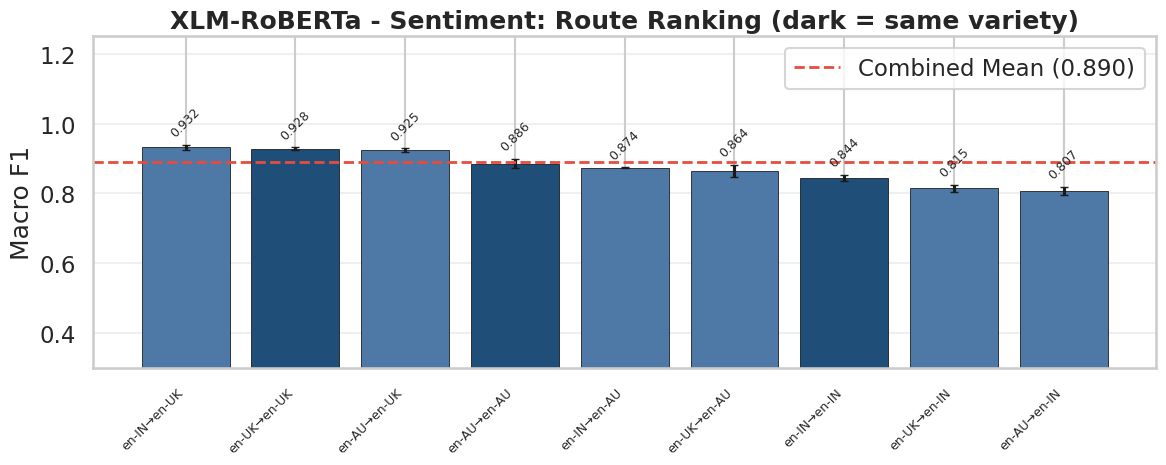

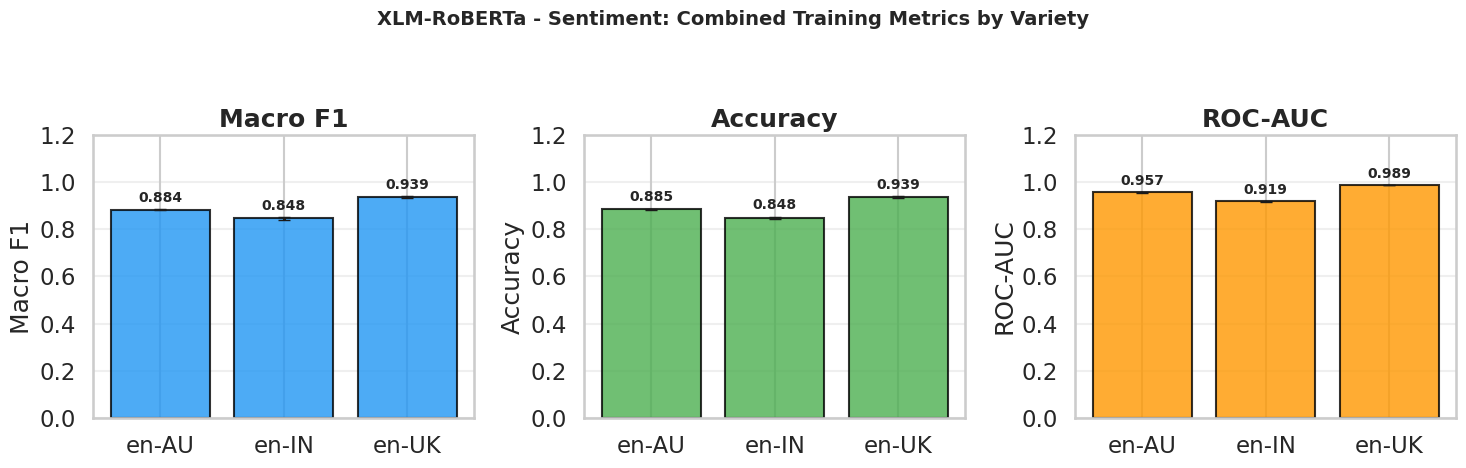

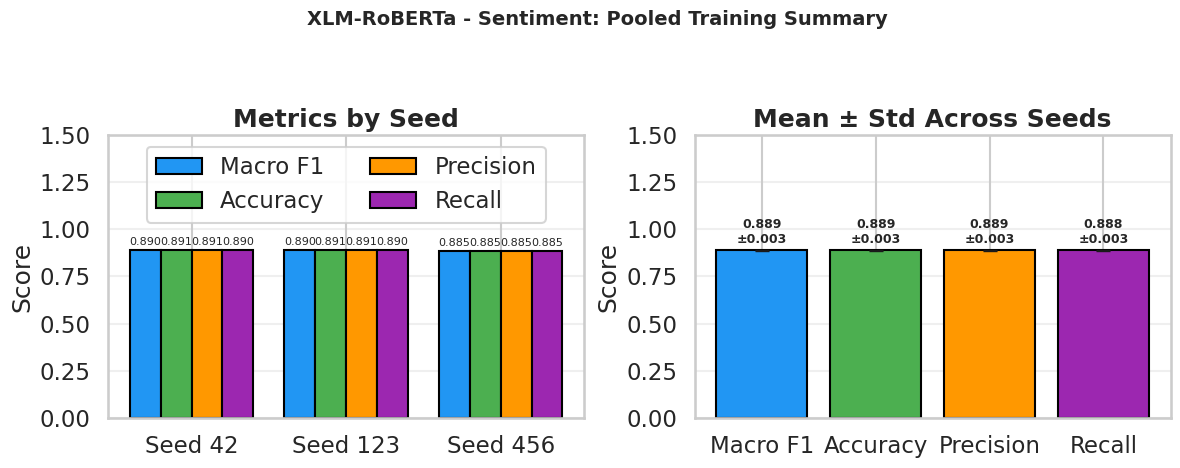

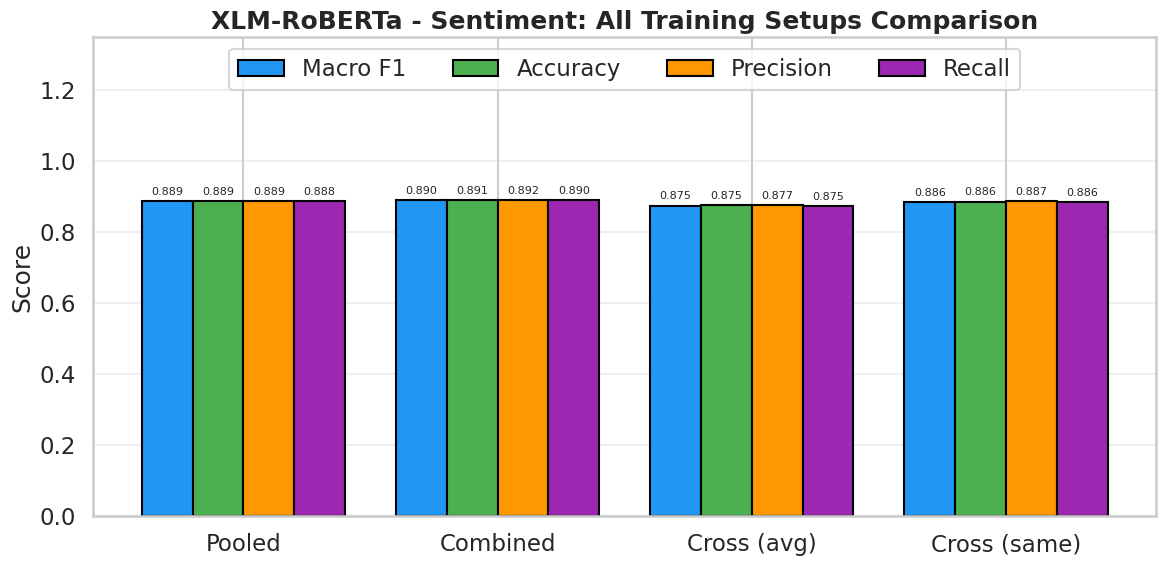

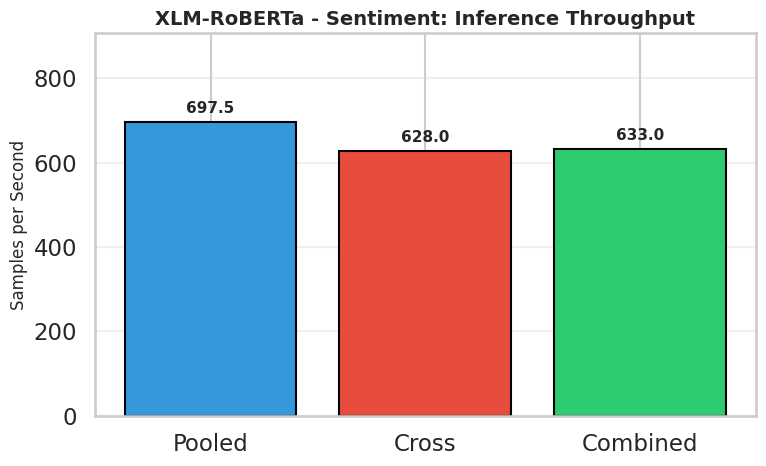

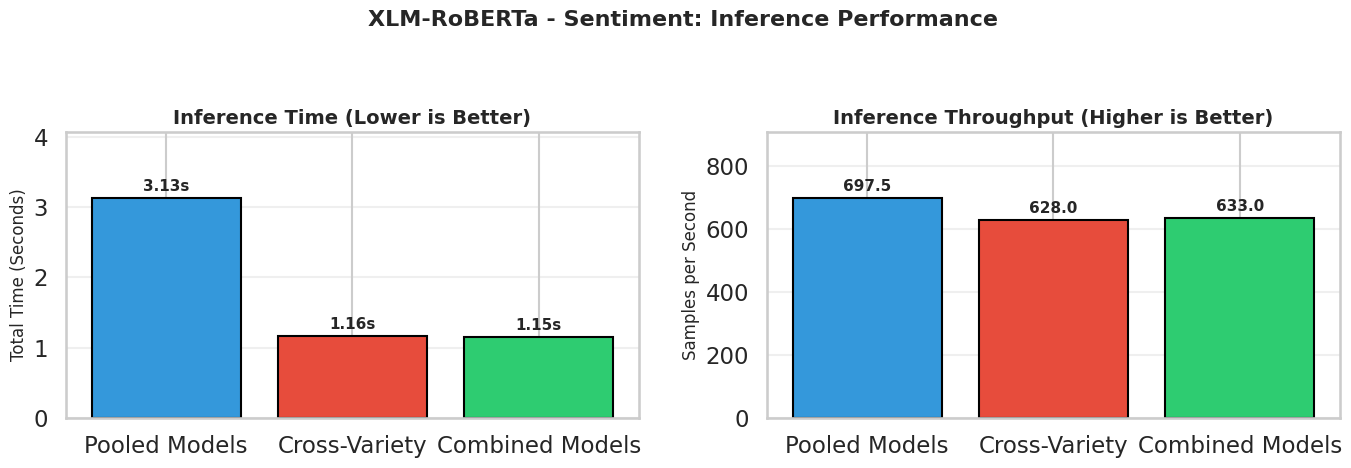


>>> All plots generated!


In [24]:
# Comprehensive plotting suite

for task_name in TASKS:
    if task_name not in all_task_results:
        continue

    task_dir         = task_out_dir(task_name)
    pooled_df_task   = all_task_results[task_name]['pooled_df']
    cross_df_task    = all_task_results[task_name]['cross_df']
    combined_df_task = all_task_results[task_name]['combined_df']

    print(f'\n>>> Generating comprehensive plots for: {task_name}')

    # 1. Route ranking
    rank = cross_df_task.copy()
    rank['route']   = rank['train_variety'] + '\u2192' + rank['test_variety']
    rank['is_same'] = rank['train_variety'] == rank['test_variety']
    rank = rank.sort_values('macro_f1_mean', ascending=False).reset_index(drop=True)

    fig, ax = plt.subplots(figsize=(12, 5))
    colors  = ['#1f4e79' if same else '#4e79a7' for same in rank['is_same']]
    bars    = ax.bar(rank.index, rank['macro_f1_mean'], yerr=rank['macro_f1_std'], capsize=3,
                     color=colors, edgecolor='black', linewidth=0.5)
    ax.bar_label(bars, fmt='%.3f', padding=4, fontsize=9, rotation=45)
    combined_mean = combined_df_task['macro_f1_mean'].mean()
    ax.axhline(combined_mean, color='#e74c3c', linestyle='--', linewidth=2, label=f'Combined Mean ({combined_mean:.3f})')
    ax.set_xticks(rank.index)
    ax.set_xticklabels(rank['route'], rotation=45, ha='right', fontsize=9)
    ax.set_ylim(0.3, 1.25); ax.set_ylabel('Macro F1')
    ax.set_title(f'{MODEL_LABEL} - {task_name}: Route Ranking (dark = same variety)', fontweight='bold')
    ax.legend(loc='upper right'); ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig(task_dir / 'route_ranking.png', dpi=150, bbox_inches='tight')
    plt.show()

    # 2. Combined metrics by variety
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    for ax, (metric, title, color) in zip(axes, [
        ('macro_f1', 'Macro F1', '#2196F3'),
        ('accuracy', 'Accuracy', '#4CAF50'),
        ('roc_auc',  'ROC-AUC',  '#FF9800'),
    ]):
        mean_col, std_col = f'{metric}_mean', f'{metric}_std'
        if mean_col in combined_df_task.columns:
            bars = ax.bar(combined_df_task['test_variety'], combined_df_task[mean_col],
                          yerr=combined_df_task.get(std_col), capsize=4, color=color, alpha=0.8, edgecolor='black')
            ax.bar_label(bars, fmt='%.3f', padding=3, fontsize=10, fontweight='bold')
        ax.set_ylim(0, 1.20); ax.set_ylabel(title)
        ax.set_title(title, fontweight='bold'); ax.grid(axis='y', alpha=0.3)
    plt.suptitle(f'{MODEL_LABEL} - {task_name}: Combined Training Metrics by Variety', fontweight='bold', fontsize=14)
    plt.tight_layout(rect=[0, 0.03, 1, 0.93])
    plt.savefig(task_dir / 'combined_metrics_detailed.png', dpi=150, bbox_inches='tight')
    plt.show()

    # 3. Pooled training summary
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    x = np.arange(len(pooled_df_task)); width = 0.2
    for offset, (col, lbl, color) in enumerate([
        ('macro_f1', 'Macro F1', '#2196F3'), ('accuracy', 'Accuracy', '#4CAF50'),
        ('macro_precision', 'Precision', '#FF9800'), ('macro_recall', 'Recall', '#9C27B0'),
    ]):
        bars = axes[0].bar(x + (offset - 1.5) * width, pooled_df_task[col], width, label=lbl, color=color, edgecolor='black')
        axes[0].bar_label(bars, fmt='%.3f', padding=2, fontsize=8)
    axes[0].set_xticks(x); axes[0].set_xticklabels([f'Seed {s}' for s in pooled_df_task['seed']])
    axes[0].set_ylim(0, 1.50); axes[0].set_ylabel('Score')
    axes[0].set_title('Metrics by Seed', fontweight='bold')
    axes[0].legend(loc='upper center', ncol=2); axes[0].grid(axis='y', alpha=0.3)

    stats   = {lbl: (pooled_df_task[col].mean(), pooled_df_task[col].std())
               for col, lbl in [('macro_f1','Macro F1'),('accuracy','Accuracy'),('macro_precision','Precision'),('macro_recall','Recall')]}
    mlabels = list(stats.keys()); means = [v[0] for v in stats.values()]; stds = [v[1] for v in stats.values()]
    axes[1].bar(mlabels, means, yerr=stds, capsize=5,
                color=['#2196F3','#4CAF50','#FF9800','#9C27B0'], edgecolor='black', linewidth=1.5)
    axes[1].set_ylim(0, 1.50); axes[1].set_ylabel('Score')
    axes[1].set_title('Mean ± Std Across Seeds', fontweight='bold')
    axes[1].grid(axis='y', alpha=0.3)
    for i, bar in enumerate(axes[1].patches):
        axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + stds[i] + 0.02,
                     f'{means[i]:.3f}\n±{stds[i]:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    plt.suptitle(f'{MODEL_LABEL} - {task_name}: Pooled Training Summary', fontweight='bold', fontsize=14)
    plt.tight_layout(rect=[0, 0.03, 1, 0.93])
    plt.savefig(task_dir / 'pooled_summary.png', dpi=150, bbox_inches='tight')
    plt.show()

    # 4. All setups comparison
    same_v = cross_df_task[cross_df_task['train_variety'] == cross_df_task['test_variety']]
    comparison_df = pd.DataFrame([
        {'Setup': 'Pooled',       'Macro F1': pooled_df_task['macro_f1'].mean(),       'Accuracy': pooled_df_task['accuracy'].mean(),       'Precision': pooled_df_task['macro_precision'].mean(),       'Recall': pooled_df_task['macro_recall'].mean()},
        {'Setup': 'Combined',     'Macro F1': combined_df_task['macro_f1_mean'].mean(), 'Accuracy': combined_df_task['accuracy_mean'].mean(), 'Precision': combined_df_task['macro_precision_mean'].mean(), 'Recall': combined_df_task['macro_recall_mean'].mean()},
        {'Setup': 'Cross (avg)',  'Macro F1': cross_df_task['macro_f1_mean'].mean(),   'Accuracy': cross_df_task['accuracy_mean'].mean(),   'Precision': cross_df_task['macro_precision_mean'].mean(),   'Recall': cross_df_task['macro_recall_mean'].mean()},
        {'Setup': 'Cross (same)', 'Macro F1': same_v['macro_f1_mean'].mean(),          'Accuracy': same_v['accuracy_mean'].mean(),          'Precision': same_v['macro_precision_mean'].mean(),          'Recall': same_v['macro_recall_mean'].mean()},
    ])
    fig, ax = plt.subplots(figsize=(12, 6))
    x = np.arange(len(comparison_df)); width = 0.2
    for i, (metric, color) in enumerate(zip(['Macro F1','Accuracy','Precision','Recall'], ['#2196F3','#4CAF50','#FF9800','#9C27B0'])):
        bars = ax.bar(x + i*width, comparison_df[metric], width, label=metric, color=color, edgecolor='black')
        ax.bar_label(bars, fmt='%.3f', padding=3, fontsize=8)
    ax.set_xticks(x + width * 1.5); ax.set_xticklabels(comparison_df['Setup'])
    ax.set_ylim(0, 1.35); ax.set_ylabel('Score')
    ax.set_title(f'{MODEL_LABEL} - {task_name}: All Training Setups Comparison', fontweight='bold')
    ax.legend(loc='upper center', ncol=4); ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig(task_dir / 'all_setups_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()

    # 5. Inference throughput
    try:
        tput = {
            'Pooled':   pooled_df_task['samples_per_sec'].mean(),
            'Cross':    cross_df_task['samples_per_sec_mean'].mean(),
            'Combined': combined_df_task['samples_per_sec_mean'].mean(),
        }
        if any(v > 0 for v in tput.values()):
            fig, ax = plt.subplots(figsize=(8, 5))
            bars = ax.bar(list(tput.keys()), list(tput.values()),
                          color=['#3498db','#e74c3c','#2ecc71'], edgecolor='black', linewidth=1.5)
            ax.set_ylim(0, max(tput.values()) * 1.30)
            for bar in bars:
                ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(tput.values())*0.02,
                        f'{bar.get_height():.1f}', ha='center', va='bottom', fontweight='bold', fontsize=11)
            ax.set_ylabel('Samples per Second', fontsize=12)
            ax.set_title(f'{MODEL_LABEL} - {task_name}: Inference Throughput', fontweight='bold', fontsize=14)
            ax.grid(axis='y', alpha=0.3)
            plt.tight_layout()
            plt.savefig(task_dir / 'inference_throughput.png', dpi=300, bbox_inches='tight')
            plt.show()
    except KeyError as e:
        print(f'  Skipping throughput plot: missing column {e}')
        
    # 5. Inference time and throughput
    if 'samples_per_sec' in pooled_df_task.columns and 'inference_time_sec' in pooled_df_task.columns:
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        
        # Prepare the data
        labels = ['Pooled Models', 'Cross-Variety', 'Combined Models']
        
        time_vals = [
            pooled_df_task['inference_time_sec'].mean(),
            cross_df_task['inference_time_sec_mean'].mean(),
            combined_df_task['inference_time_sec_mean'].mean()
        ]
        
        throughput_vals = [
            pooled_df_task['samples_per_sec'].mean(),
            cross_df_task['samples_per_sec_mean'].mean(),
            combined_df_task['samples_per_sec_mean'].mean()
        ]
        
        colors = ['#3498db', '#e74c3c', '#2ecc71']
        
        # Chart 1: inference time (total seconds)
        if any(v > 0 for v in time_vals):
            bars_time = axes[0].bar(labels, time_vals, color=colors, edgecolor='black', linewidth=1.5)
            axes[0].set_ylim(0, max(time_vals) * 1.30)
            
            for bar in bars_time: 
                axes[0].text(bar.get_x() + bar.get_width()/2.0, bar.get_height() + (max(time_vals)*0.02), 
                             f'{bar.get_height():.2f}s', ha='center', va='bottom', fontweight='bold', fontsize=11)
                
            axes[0].set_ylabel('Total Time (Seconds)', fontsize=12)
            axes[0].set_title('Inference Time (Lower is Better)', fontweight='bold', fontsize=14)
            axes[0].grid(axis='y', alpha=0.3)
        
        # Chart 2: inference throughput (samples per second)
        if any(v > 0 for v in throughput_vals):
            bars_tput = axes[1].bar(labels, throughput_vals, color=colors, edgecolor='black', linewidth=1.5)
            axes[1].set_ylim(0, max(throughput_vals) * 1.30)
            
            for bar in bars_tput: 
                axes[1].text(bar.get_x() + bar.get_width()/2.0, bar.get_height() + (max(throughput_vals)*0.02), 
                             f'{bar.get_height():.1f}', ha='center', va='bottom', fontweight='bold', fontsize=11)
                
            axes[1].set_ylabel('Samples per Second', fontsize=12)
            axes[1].set_title('Inference Throughput (Higher is Better)', fontweight='bold', fontsize=14)
            axes[1].grid(axis='y', alpha=0.3)
        
        plt.suptitle(f'{MODEL_LABEL} - {task_name}: Inference Performance', fontweight='bold', fontsize=16)
        plt.tight_layout(rect=[0, 0.03, 1, 0.93])
        plt.savefig(task_dir / 'inference_performance.png', dpi=300, bbox_inches='tight')
        plt.show()
    else:
        print("  Skipping Inference plot: Missing time metrics in DataFrame.")

print('\n>>> All plots generated!')

## Fine-Tune Utility Cells (Manual)

Use these cells for quick one-off fine-tuning runs without re-running the full pipeline.


In [19]:
# Fine-tune utility configuration
FT_RUN_ALL        = False      # True => sweep all combos
FT_TASK           = 'Sentiment'
FT_MODE           = 'pooled'   # 'pooled' | 'cross' | 'combined'
FT_SEED           = 42
FT_TRAIN_VARIETY  = 'en-UK'    # only used for FT_MODE='cross'

FT_TASKS           = ['Sentiment']
FT_MODES           = ['pooled', 'cross', 'combined']
FT_SEEDS           = SEEDS[:]
FT_TRAIN_VARIETIES = VARIETIES[:]

print('Fine-Tune Utility Config:')
print(f'  FT_RUN_ALL = {FT_RUN_ALL}')
if FT_RUN_ALL:
    total = len(FT_TASKS) * (len(FT_SEEDS)*2 + len(FT_SEEDS)*len(FT_TRAIN_VARIETIES))
    print(f'  Total runs: {total}')
else:
    print(f'  Task={FT_TASK}  Mode={FT_MODE}  Seed={FT_SEED}')
    if FT_MODE == 'cross':
        print(f'  Train variety: {FT_TRAIN_VARIETY}')

Fine-Tune Utility Config:
  FT_RUN_ALL = False
  Task=Sentiment  Mode=pooled  Seed=42



Running SINGLE fine-tune config...

  [Sentiment] Pooled training, seed=42


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.bias                | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
classifier.dense.bias       | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.out_proj.weight  | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


  Trainable: 3,246,338 / 281,291,524 (1.15%)
  Using WeightedTrainer with class weights


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Macro Precision,Macro Recall,Weighted F1,Weighted Precision,Weighted Recall,Class 0 F1,Class 1 F1,Roc Auc,Avg Precision
1,0.973574,0.343115,0.897764,0.897712,0.900316,0.898713,0.897661,0.901167,0.897764,0.895425,0.900000,0.919220,0.874797
2,0.663725,0.302331,0.884984,0.884559,0.894751,0.886785,0.884402,0.896270,0.884984,0.877551,0.891566,0.969751,0.975960
3,0.613418,0.191034,0.932907,0.932863,0.932944,0.932802,0.932902,0.932915,0.932907,0.934579,0.931148,0.977083,0.980284
4,0.493223,0.207653,0.923323,0.923322,0.923609,0.923713,0.923327,0.924011,0.923323,0.923567,0.923077,0.973877,0.977464


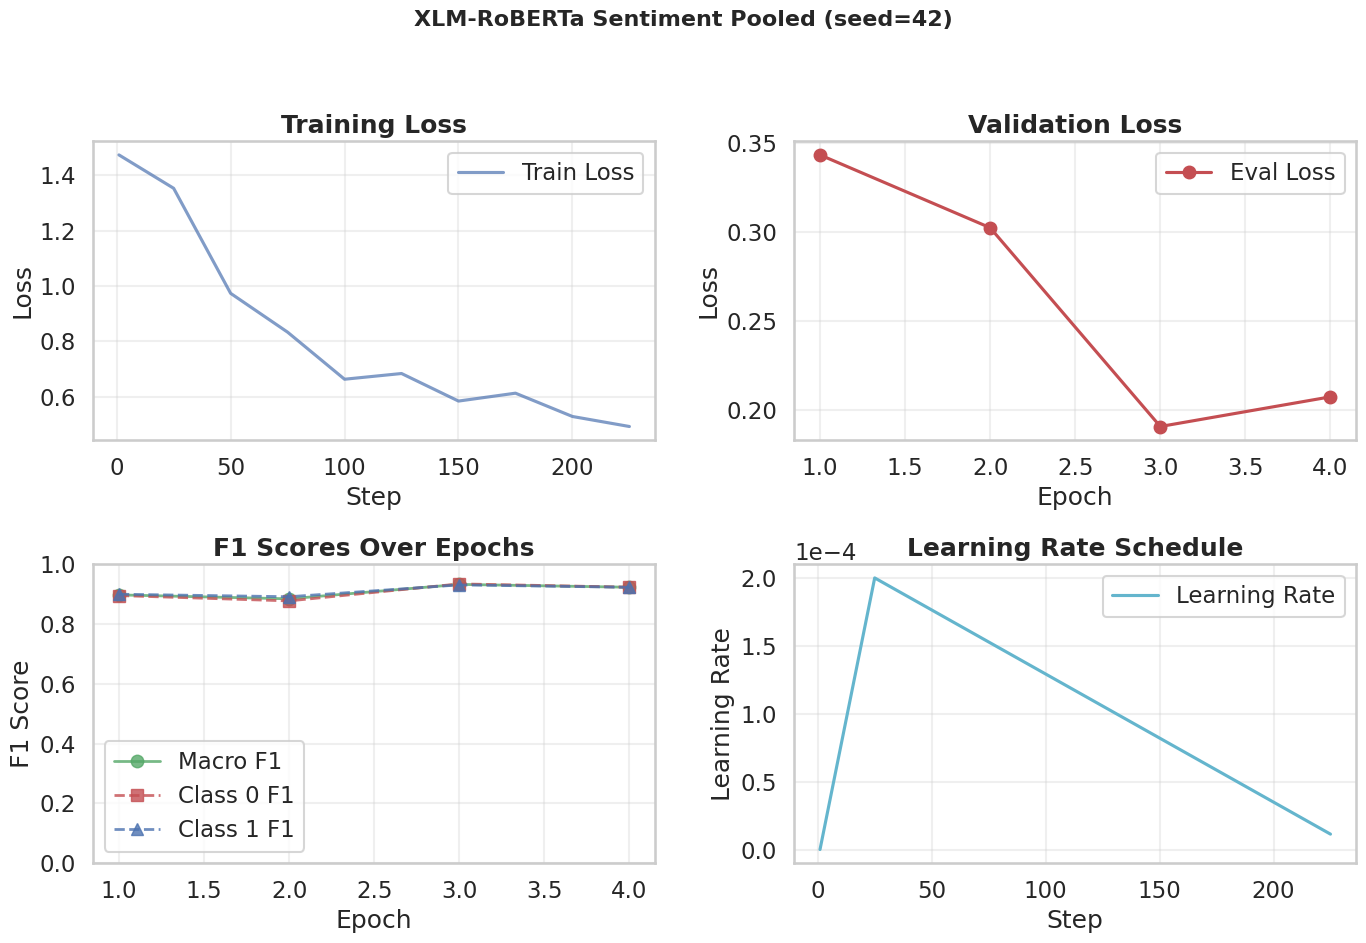

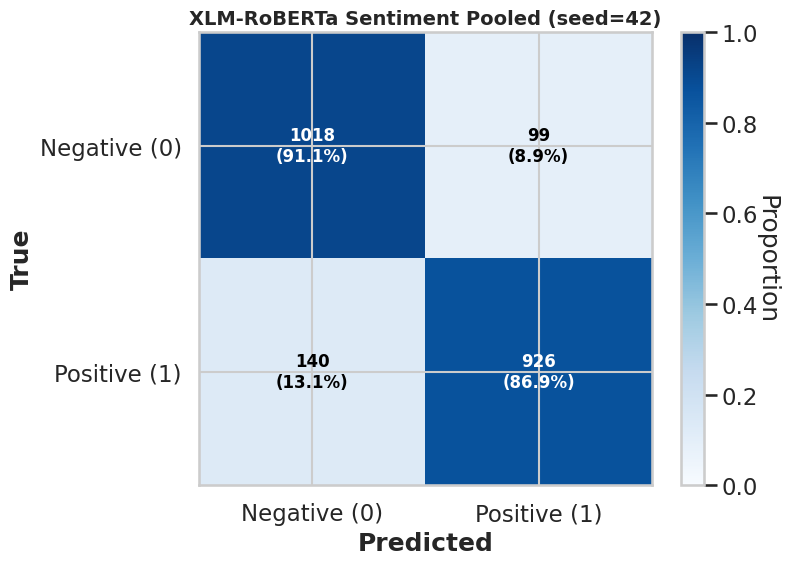

    -> Macro F1: 0.8903  Accuracy: 0.8905

Results: F1=0.8903  Accuracy=0.8905

FINE-TUNING COMPLETED
Saved: /scratch/HS400/outputs_xlmroberta/fine_tune_runs_20260415_153550.csv
     task   mode  seed train_variety test_variety  macro_f1  accuracy
Sentiment pooled    42           ALL     ALL_TEST  0.890323  0.890518


In [20]:
# Run fine-tuning from the config above
from datetime import datetime

results_rows = []

if FT_RUN_ALL:
    print(f"\n{'='*60}\nRunning FULL fine-tuning sweep...\n{'='*60}")
    for task_name in FT_TASKS:
        for mode in FT_MODES:
            for seed in FT_SEEDS:
                if mode == 'pooled':
                    r = run_pooled_for_task(task_name, seed, save_plots=False)
                    results_rows.append({'task': task_name, 'mode': mode, 'seed': seed,
                                         'train_variety': 'ALL', 'test_variety': 'ALL_TEST',
                                         'accuracy': r['accuracy'], 'macro_f1': r['macro_f1'],
                                         'precision': r['macro_precision'], 'recall': r['macro_recall'],
                                         'roc_auc': r.get('roc_auc', np.nan),
                                         'checkpoint_dir': r['checkpoint_dir'], 'final_model_dir': r['final_model_dir']})
                    print(f'[DONE] {task_name} | pooled | seed={seed} | F1={r["macro_f1"]:.4f}')

                elif mode == 'combined':
                    r = run_combined_for_task(task_name, seed, save_plots=False)
                    meta = r.get('_meta', {})
                    for tv in VARIETIES:
                        results_rows.append({'task': task_name, 'mode': mode, 'seed': seed,
                                             'train_variety': 'ALL', 'test_variety': tv,
                                             'accuracy': r[tv]['accuracy'], 'macro_f1': r[tv]['macro_f1'],
                                             'precision': r[tv]['macro_precision'], 'recall': r[tv]['macro_recall'],
                                             'roc_auc': r[tv].get('roc_auc', np.nan),
                                             'checkpoint_dir': meta.get('checkpoint_dir', ''),
                                             'final_model_dir': meta.get('final_model_dir', '')})
                    print(f'[DONE] {task_name} | combined | seed={seed}')

                elif mode == 'cross':
                    for tr in FT_TRAIN_VARIETIES:
                        r = run_cross_for_task(task_name, tr, seed, save_plots=False)
                        meta = r.get('_meta', {})
                        for tv in VARIETIES:
                            results_rows.append({'task': task_name, 'mode': mode, 'seed': seed,
                                                 'train_variety': tr, 'test_variety': tv,
                                                 'accuracy': r[tv]['accuracy'], 'macro_f1': r[tv]['macro_f1'],
                                                 'precision': r[tv]['macro_precision'], 'recall': r[tv]['macro_recall'],
                                                 'roc_auc': r[tv].get('roc_auc', np.nan),
                                                 'checkpoint_dir': meta.get('checkpoint_dir', ''),
                                                 'final_model_dir': meta.get('final_model_dir', '')})
                        print(f'[DONE] {task_name} | cross | train={tr} | seed={seed}')
else:
    print(f"\n{'='*60}\nRunning SINGLE fine-tune config...\n{'='*60}")
    if FT_MODE == 'pooled':
        r = run_pooled_for_task(FT_TASK, FT_SEED, save_plots=True)
        results_rows.append({'task': FT_TASK, 'mode': FT_MODE, 'seed': FT_SEED,
                              'train_variety': 'ALL', 'test_variety': 'ALL_TEST',
                              'accuracy': r['accuracy'], 'macro_f1': r['macro_f1'],
                              'precision': r['macro_precision'], 'recall': r['macro_recall'],
                              'roc_auc': r.get('roc_auc', np.nan),
                              'checkpoint_dir': r['checkpoint_dir'], 'final_model_dir': r['final_model_dir']})
        print(f'\nResults: F1={r["macro_f1"]:.4f}  Accuracy={r["accuracy"]:.4f}')

    elif FT_MODE == 'combined':
        r = run_combined_for_task(FT_TASK, FT_SEED, save_plots=True)
        meta = r.get('_meta', {})
        for tv in VARIETIES:
            results_rows.append({'task': FT_TASK, 'mode': FT_MODE, 'seed': FT_SEED,
                                  'train_variety': 'ALL', 'test_variety': tv,
                                  'accuracy': r[tv]['accuracy'], 'macro_f1': r[tv]['macro_f1'],
                                  'precision': r[tv]['macro_precision'], 'recall': r[tv]['macro_recall'],
                                  'roc_auc': r[tv].get('roc_auc', np.nan),
                                  'checkpoint_dir': meta.get('checkpoint_dir', ''),
                                  'final_model_dir': meta.get('final_model_dir', '')})
        print('\nResults by variety:')
        for tv in VARIETIES: print(f'  {tv}: F1={r[tv]["macro_f1"]:.4f}')

    elif FT_MODE == 'cross':
        r = run_cross_for_task(FT_TASK, FT_TRAIN_VARIETY, FT_SEED, save_plots=True)
        meta = r.get('_meta', {})
        for tv in VARIETIES:
            results_rows.append({'task': FT_TASK, 'mode': FT_MODE, 'seed': FT_SEED,
                                  'train_variety': FT_TRAIN_VARIETY, 'test_variety': tv,
                                  'accuracy': r[tv]['accuracy'], 'macro_f1': r[tv]['macro_f1'],
                                  'precision': r[tv]['macro_precision'], 'recall': r[tv]['macro_recall'],
                                  'roc_auc': r[tv].get('roc_auc', np.nan),
                                  'checkpoint_dir': meta.get('checkpoint_dir', ''),
                                  'final_model_dir': meta.get('final_model_dir', '')})
        print(f'\nResults (trained on {FT_TRAIN_VARIETY}):')
        for tv in VARIETIES: print(f'  → {tv}: F1={r[tv]["macro_f1"]:.4f}')
    else:
        raise ValueError(f'FT_MODE must be pooled | cross | combined. Got: {FT_MODE}')

if results_rows:
    ft_df    = pd.DataFrame(results_rows)
    ts       = datetime.now().strftime('%Y%m%d_%H%M%S')
    out_csv  = OUT_DIR / f'fine_tune_runs_{ts}.csv'
    ft_df.to_csv(out_csv, index=False)
    print(f"\n{'='*60}\nFINE-TUNING COMPLETED\n{'='*60}")
    print(f'Saved: {out_csv}')
    print(ft_df[['task','mode','seed','train_variety','test_variety','macro_f1','accuracy']].to_string(index=False))

## Qualitative Error Analysis


In [ ]:
# Qualitative error analysis (XLM-RoBERTa)
from peft import PeftModel


def run_error_analysis(task_name: str = 'Sentiment', seed: int = 42):
    print(f"\n{'='*60}")
    print(f'QUALITATIVE ERROR ANALYSIS: {task_name.upper()}')
    print(f"{'='*60}")

    pos_label, neg_label = 'POSITIVE', 'NEGATIVE'  # Sentiment only
    lbl_col   = get_label_col(task_name)
    model_dir = task_out_dir(task_name) / 'final_models' / f'{MODEL_LABEL.lower().replace("-","")}_{task_name.lower()}_pooled_seed{seed}'

    if not model_dir.exists():
        print(f'Model not found at {model_dir}')
        return

    print(f'Loading base {MODEL_NAME}...')
    base_model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2).to(DEVICE)

    # Try loading as LoRA; fall back to plain weights if it is not a PEFT checkpoint.
    try:
        print(f'Loading LoRA adapters from {model_dir}...')
        model = PeftModel.from_pretrained(base_model, str(model_dir)).to(DEVICE)
    except Exception:
        print('  Not a PEFT checkpoint  loading as full fine-tuned model.')
        model = AutoModelForSequenceClassification.from_pretrained(str(model_dir), num_labels=2).to(DEVICE)
    model.eval()

    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True)

    te_texts  = list(pooled['test'][text_col])
    te_labels = [int(x) for x in pooled['test'][lbl_col]]
    te_ds     = TextDataset(te_texts, te_labels, tokenizer, MAX_LEN)

    trainer     = Trainer(model=model, data_collator=IntLabelDataCollator(tokenizer))
    preds_out   = trainer.predict(te_ds)
    probs       = torch.softmax(torch.tensor(preds_out.predictions), dim=-1).numpy()
    y_pred      = np.argmax(probs, axis=-1)

    errors = sorted(
        [{'text': te_texts[i], 'true': te_labels[i], 'pred': y_pred[i], 'confidence': probs[i][y_pred[i]]}
         for i in range(len(te_labels)) if te_labels[i] != y_pred[i]],
        key=lambda x: x['confidence'], reverse=True,
    )

    print(f'\n🚨 TOP 5 FALSE POSITIVES 🚨')
    print(f'({neg_label} text the model was HIGHLY CONFIDENT was {pos_label})')
    for i, e in enumerate([e for e in errors if e['pred'] == 1 and e['true'] == 0][:5]):
        print(f'\n{i+1}. [Conf: {e["confidence"]:.4f}] {e["text"]}')

    print(f'\n\n🚨 TOP 5 FALSE NEGATIVES 🚨')
    print(f'({pos_label} text the model was HIGHLY CONFIDENT was {neg_label})')
    for i, e in enumerate([e for e in errors if e['pred'] == 0 and e['true'] == 1][:5]):
        print(f'\n{i+1}. [Conf: {e["confidence"]:.4f}] {e["text"]}')

    del model, base_model, trainer
    if torch.cuda.is_available(): torch.cuda.empty_cache()


run_error_analysis('Sentiment')


QUALITATIVE ERROR ANALYSIS: SENTIMENT
Loading base xlm-roberta-base...


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.bias                | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
classifier.dense.bias       | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.out_proj.weight  | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading LoRA adapters from /scratch/HS400/outputs_xlmroberta/sentiment/final_models/xlmroberta_sentiment_pooled_seed42...



🚨 TOP 5 FALSE POSITIVES 🚨
(NEGATIVE text the model was HIGHLY CONFIDENT was POSITIVE)

1. [Conf: 0.9898] Puff and some of the cakes are just superb, and well priced. Puff I had there some 15years back and then now, and it tastes same. It is perfectly priced as well. Eat it hot. Other Bakery items are also good, but there are better options available for those items.

2. [Conf: 0.9890] First time at Neighbourhood today. Went down with my life, little girl( 2) and our friend with 2 kids of her own. Pretty busy as expected for a new business in a good location outside of the Warragul CBD area. Greeting from staff was great and welcoming after we managed to wind our way through the tables to our booth seating. Young lady who served us was very attentive and made sure she got our orders correct by reading them back. I appreciated this very much. Our coffee came out first, I ordered a vanilla latte and was unfortunately disappointed with the temperature and the flavour. Overboard on vanilla

Looking for RoBERTa results...
  cross_variety_results_q2_2.csv : all_outputs/cross_variety_results_q2_2.csv
  q3_eval_sentiment.csv          : None

COMPARISON: XLM-RoBERTa vs RoBERTa (Cross-Variety)

Per-route comparison:
  en-AU→en-AU: XLM-RoBERTa=0.8855, RoBERTa=0.8929, Δ=-0.0074 ↓
  en-AU→en-IN: XLM-RoBERTa=0.8071, RoBERTa=0.8215, Δ=-0.0144 ↓
  en-AU→en-UK: XLM-RoBERTa=0.9246, RoBERTa=0.9399, Δ=-0.0153 ↓
  en-IN→en-AU: XLM-RoBERTa=0.8740, RoBERTa=0.8913, Δ=-0.0172 ↓
  en-IN→en-IN: XLM-RoBERTa=0.8443, RoBERTa=0.8410, Δ=+0.0032 ↑
  en-IN→en-UK: XLM-RoBERTa=0.9323, RoBERTa=0.9392, Δ=-0.0070 ↓
  en-UK→en-AU: XLM-RoBERTa=0.8638, RoBERTa=0.8634, Δ=+0.0004 ↑
  en-UK→en-IN: XLM-RoBERTa=0.8145, RoBERTa=0.8451, Δ=-0.0306 ↓
  en-UK→en-UK: XLM-RoBERTa=0.9279, RoBERTa=0.9493, Δ=-0.0213 ↓

Overall:
  XLM-RoBERTa mean F1: 0.8749
  RoBERTa mean F1:  0.8871
  Average advantage: -0.0122


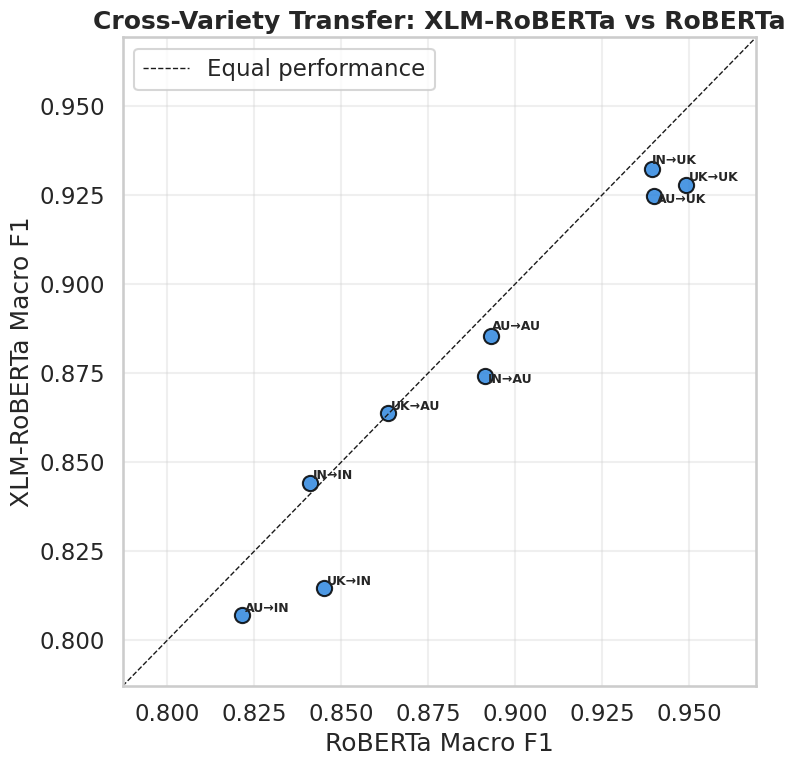

In [ ]:
# External comparison with existing RoBERTa results
roberta_cross_path = find_file('cross_variety_results_q2_2.csv')
roberta_q3_path    = find_file('q3_eval_sentiment.csv')

print('Looking for RoBERTa results...')
print(f'  cross_variety_results_q2_2.csv : {roberta_cross_path}')
print(f'  q3_eval_sentiment.csv          : {roberta_q3_path}')

task_name     = 'Sentiment'
cross_df_task = all_task_results[task_name]['cross_df']

if roberta_cross_path is not None:
    print(f"\n{'='*60}\nCOMPARISON: {MODEL_LABEL} vs RoBERTa (Cross-Variety)\n{'='*60}")
    rob_df = pd.read_csv(roberta_cross_path)
    if 'macro_f1_mean' not in rob_df.columns and 'f1_mean' in rob_df.columns:
        rob_df['macro_f1_mean'] = rob_df['f1_mean']

    lbl = MODEL_LABEL.lower().replace('-', '')
    merged = cross_df_task.merge(
        rob_df[['train_variety', 'test_variety', 'macro_f1_mean']],
        on=['train_variety', 'test_variety'],
        suffixes=(f'_{lbl}', '_roberta'),
    )

    if not merged.empty:
        merged['advantage'] = merged[f'macro_f1_mean_{lbl}'] - merged['macro_f1_mean_roberta']

        print('\nPer-route comparison:')
        for _, row in merged.iterrows():
            route = f"{row['train_variety']}→{row['test_variety']}"
            ours  = row[f'macro_f1_mean_{lbl}']
            rob   = row['macro_f1_mean_roberta']
            adv   = row['advantage']
            print(f'  {route}: {MODEL_LABEL}={ours:.4f}, RoBERTa={rob:.4f}, Δ={adv:+.4f} {"↑" if adv>0 else "↓"}')

        print(f'\nOverall:')
        print(f'  {MODEL_LABEL} mean F1: {merged[f"macro_f1_mean_{lbl}"].mean():.4f}')
        print(f'  RoBERTa mean F1:  {merged["macro_f1_mean_roberta"].mean():.4f}')
        print(f'  Average advantage: {merged["advantage"].mean():+.4f}')

        fig, ax = plt.subplots(figsize=(8, 8))
        ax.scatter(merged['macro_f1_mean_roberta'], merged[f'macro_f1_mean_{lbl}'],
                   s=120, c='#2e86de', edgecolor='black', alpha=0.85)
        lim = [min(merged['macro_f1_mean_roberta'].min(), merged[f'macro_f1_mean_{lbl}'].min()) - 0.02,
               max(merged['macro_f1_mean_roberta'].max(), merged[f'macro_f1_mean_{lbl}'].max()) + 0.02]
        ax.plot(lim, lim, 'k--', linewidth=1, label='Equal performance')
        ax.set_xlim(lim); ax.set_ylim(lim)
        ax.set_xlabel('RoBERTa Macro F1'); ax.set_ylabel(f'{MODEL_LABEL} Macro F1')
        ax.set_title(f'Cross-Variety Transfer: {MODEL_LABEL} vs RoBERTa', fontweight='bold')
        ax.legend(loc='upper left'); ax.grid(alpha=0.3)
        texts_list = []
        for _, row in merged.iterrows():
            route = f"{str(row['train_variety']).replace('en-','')}→{str(row['test_variety']).replace('en-','')}"
            texts_list.append(ax.text(row['macro_f1_mean_roberta'], row[f'macro_f1_mean_{lbl}'],
                                      route, fontsize=9, fontweight='bold'))
        try:
            from adjustText import adjust_text
            adjust_text(texts_list, arrowprops=dict(arrowstyle='-', color='gray', lw=0.8, alpha=0.7))
        except ImportError:
            pass
        plt.tight_layout()
        plt.savefig(OUT_DIR / 'cross_variety_vs_roberta.png', dpi=150, bbox_inches='tight')
        plt.show()
        merged.to_csv(OUT_DIR / 'cross_variety_comparison_with_roberta.csv', index=False)
else:
    print('\nNo RoBERTa results found for comparison  skipping.')

In [ ]:
# Find best models for deployment
target_varieties = ['en-AU', 'en-IN', 'en-UK']

print(f"{'='*80}")
print(f'SEARCHING FOR BEST DEPLOYMENT MODELS ({MODEL_LABEL})')
print(f"{'='*80}")

for task_name in TASKS:
    if task_name not in all_task_results:
        print(f'\n No data found for {task_name}.')
        continue

    print(f'\n\n  BEST MODELS FOR: {task_name.upper()} ')
    print('-' * 50)

    res             = all_task_results[task_name]
    cross_raw       = res['cross_raw']
    combined_raw    = res['combined_raw']
    pooled_results  = res['pooled_results']

    for tv in target_varieties:
        best_f1, best_info = -1, {}

        # A. Cross-variety runs
        for (train_var, seed), test_metrics in cross_raw.items():
            if tv in test_metrics:
                f1 = test_metrics[tv].get('macro_f1', 0)
                if f1 > best_f1:
                    best_f1   = f1
                    best_info = {'strategy': f'Single-Variety (trained on {train_var})', 'seed': seed, 'f1': f1,
                                 'path': test_metrics.get('_meta', {}).get('final_model_dir', 'N/A')}

        # B. Combined runs
        for seed, test_metrics in combined_raw.items():
            if tv in test_metrics:
                f1 = test_metrics[tv].get('macro_f1', 0)
                if f1 > best_f1:
                    best_f1   = f1
                    best_info = {'strategy': 'Combined Training (all varieties)', 'seed': seed, 'f1': f1,
                                 'path': test_metrics.get('_meta', {}).get('final_model_dir', 'N/A')}

        if best_f1 > -1:
            print(f'Target: {tv}')
            print(f'   Strategy:       {best_info["strategy"]}')
            print(f'   Macro F1:       {best_info["f1"]:.4f}')
            print(f'   Model path:  {best_info["path"]}\n')

    # C. Best pooled model (generic / all regions)
    print('Target: GENERIC / ALL REGIONS (Pooled Model)')
    best_p = max(pooled_results, key=lambda r: r['macro_f1'])
    print(f'   Strategy:       Pooled Training (best across all data)')
    print(f'   Macro F1:       {best_p["macro_f1"]:.4f}')
    print(f'   Model path:  {best_p.get("final_model_dir", "N/A")}\n')

🔍 SEARCHING FOR BEST DEPLOYMENT MODELS (XLM-RoBERTa)


🏆  BEST MODELS FOR: SENTIMENT 🏆
--------------------------------------------------
🎯 Target: en-AU
   Strategy:       Single-Variety (trained on en-AU)
   Macro F1:       0.8973
   📁 Model path:  /scratch/HS400/outputs_xlmroberta/sentiment/final_models/xlmroberta_sentiment_cross_train-en-AU_seed456

🎯 Target: en-IN
   Strategy:       Combined Training (all varieties)
   Macro F1:       0.8549
   📁 Model path:  /scratch/HS400/outputs_xlmroberta/sentiment/final_models/xlmroberta_sentiment_combined_seed42

🎯 Target: en-UK
   Strategy:       Combined Training (all varieties)
   Macro F1:       0.9414
   📁 Model path:  /scratch/HS400/outputs_xlmroberta/sentiment/final_models/xlmroberta_sentiment_combined_seed42

🎯 Target: GENERIC / ALL REGIONS (Pooled Model)
   Strategy:       Pooled Training (best across all data)
   Macro F1:       0.8904
   📁 Model path:  /scratch/HS400/outputs_xlmroberta/sentiment/final_models/xlmroberta_sentiment_p